In [1]:
import os
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
import importlib, spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    find_temporal_transitions,
    plot_temporal_transitions,
    plot_temporal_transitions_highlights,
    analyze_lfp_at_transitions,
    plot_lfp_block_comparison,
    plot_lfp_transition_validation,
    plot_transition_deltas,
    plot_transition_deltas_signed_mean,
    plot_transition_deltas_by_celltype,
)
import config
from config import SPE1_PICKLE_ROOT, DICT_CELL_TYPE

In [ ]:
# ── Run-control flags ───────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


In [3]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

## Temporal transition times

For each (cell × spike_feature) pair with enough spikes, fit a 4-parameter logistic sigmoid to the rolling mean of ordinal cluster labels:

```
y = b + L / (1 + exp(-k·(t − t₀)))
```

**t₀** is the transition time (inflection point).  **k** (1/s) is the sharpness — large |k| = abrupt switch, small |k| = gradual drift.  **R²** measures how well the sigmoid explains the rolling mean.  A pair is kept as a transition only if R² ≥ threshold *and* |k| ≥ minimum sharpness — no Spearman pre-screening.

In [ ]:
FORCE_TRANSITIONS = True  # recompute after threshold change; set False after first run  # set True to recompute and overwrite the cache

transition_save_path = os.path.join(config.SPE1_PICKLE_ROOT, 'cluster_pickles', 'temporal_transitions.pkl')

df_transitions = find_temporal_transitions(
    cluster_pickle_dir,
    r2_thresh=0.80,
    min_k=0.003,
    min_spikes=20,
    rolling_n=50,
    max_sigs=3,
    save_path=transition_save_path,
    force=FORCE_TRANSITIONS,
)
df_transitions


TypeError: issubclass() arg 1 must be a class

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2664: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


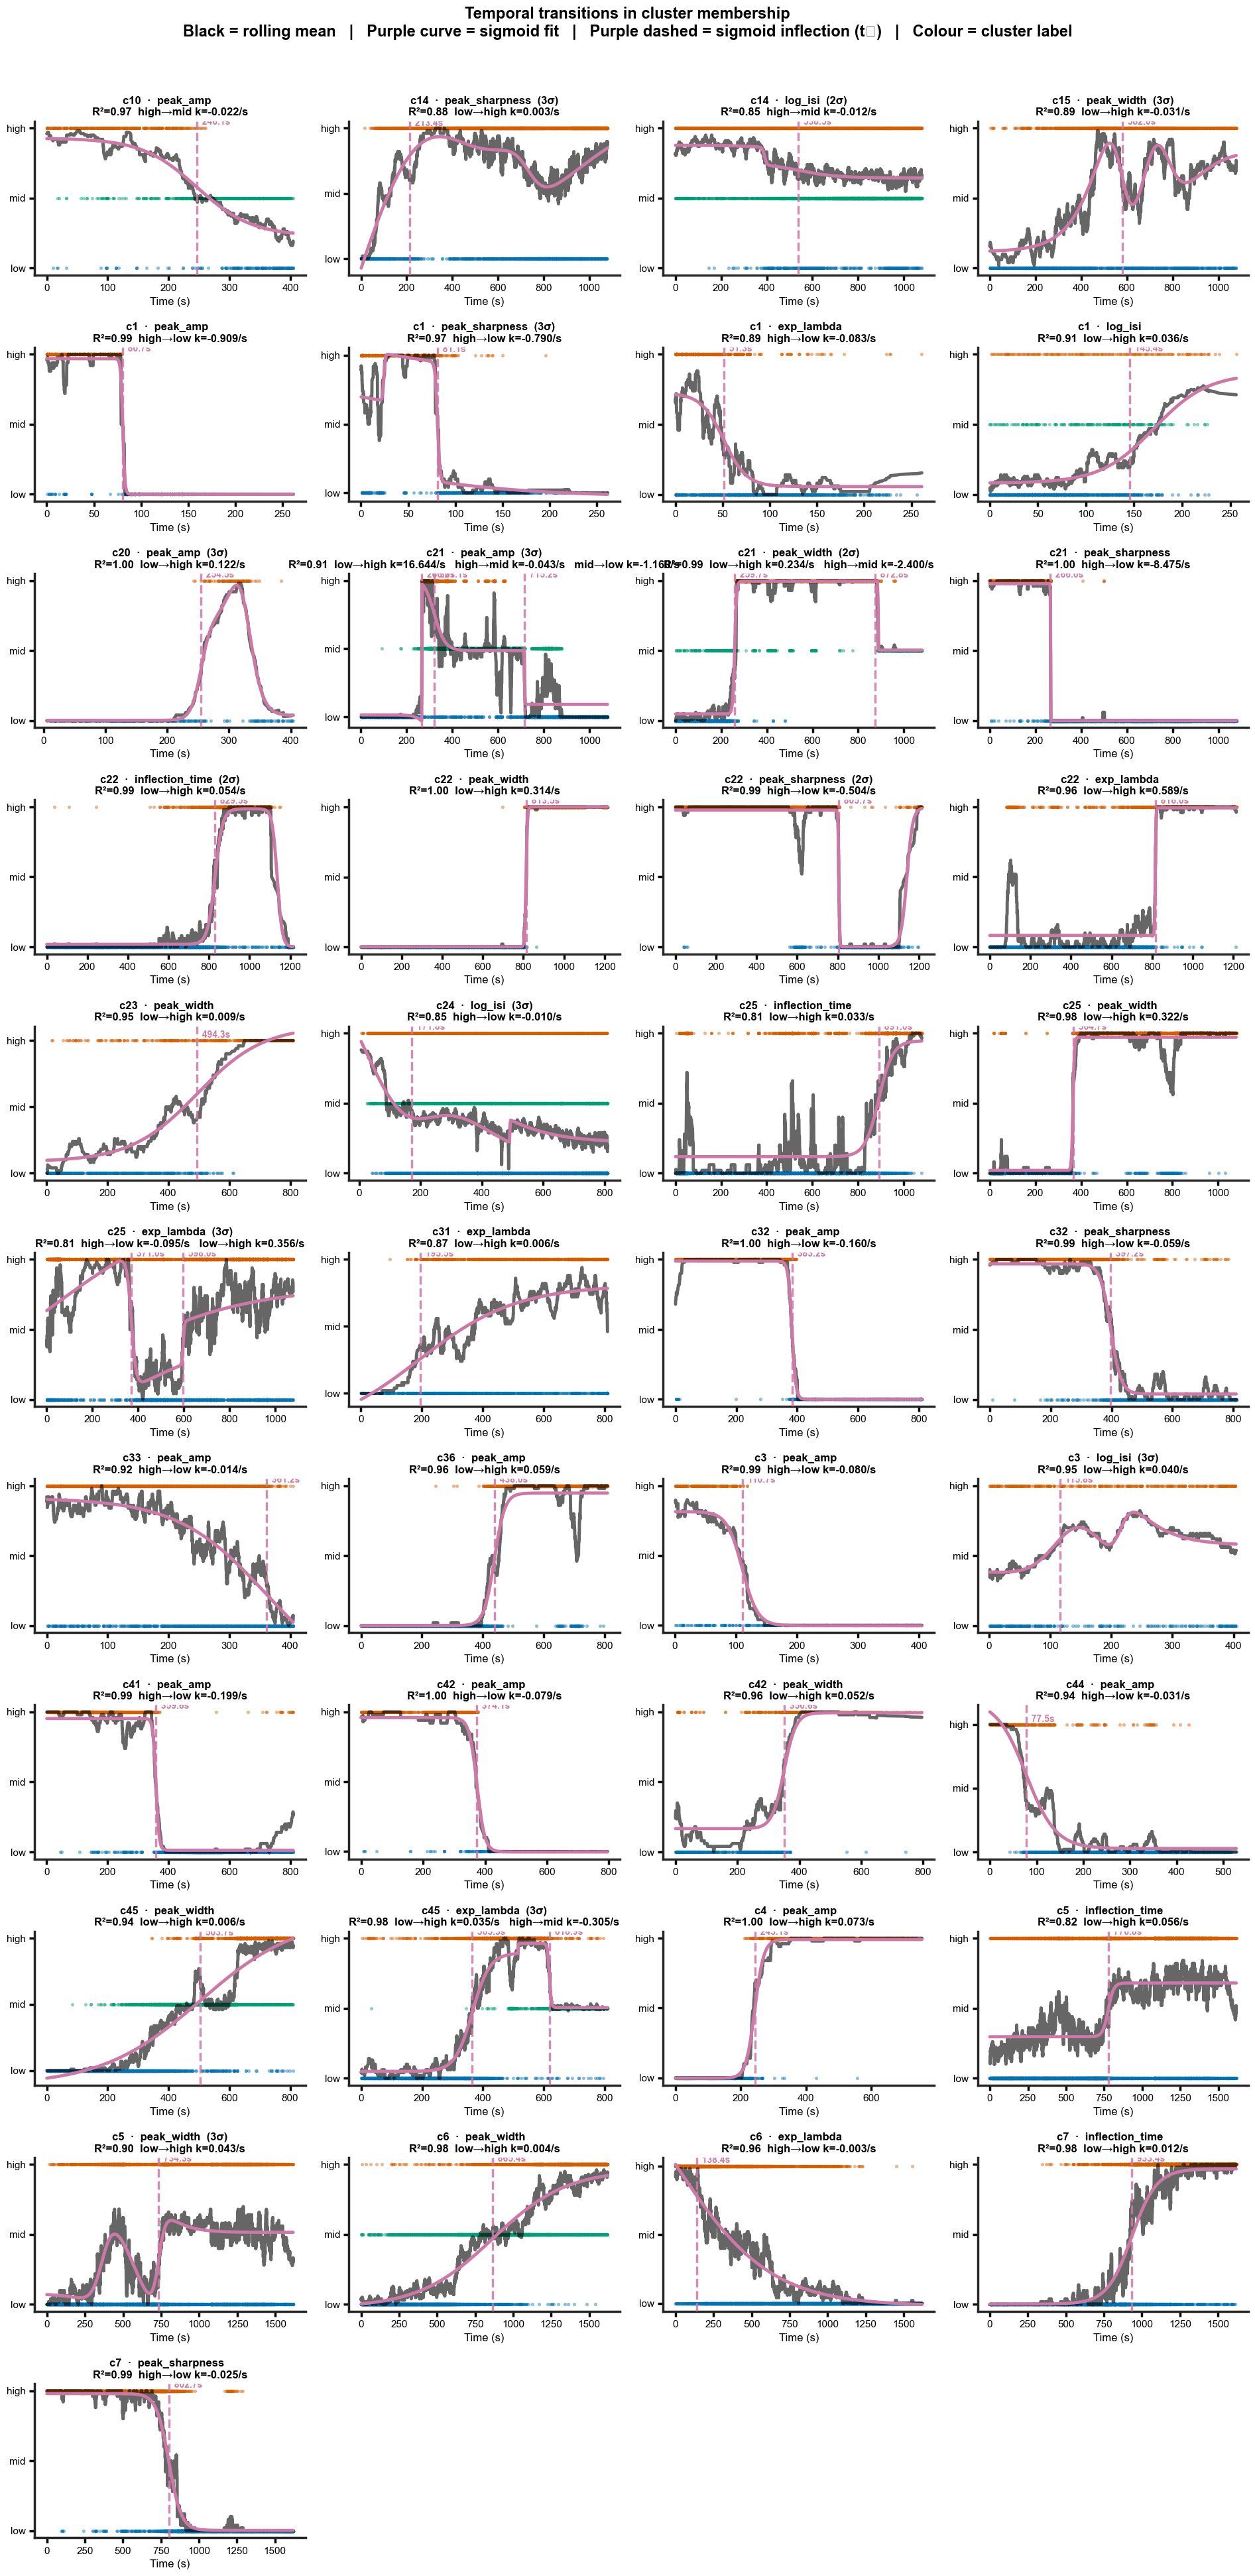

In [ ]:
plot_temporal_transitions(df_transitions, cluster_pickle_dir, n_cols=4, rolling_n=50)

## LFP state at the transition

For each (cell × spike-feature) pair, extract two LFP epochs: one immediately before and one
immediately after the detected transition time. Spectral features (θ AUC, slow γ AUC, high γ AUC,
total γ AUC, aperiodic exponent, mean amplitude, amplitude SD) are computed for each epoch using
specparam on a multitaper PSD.

The block boundaries are set to span all spikes before / after the transition, up to a maximum
window of the full recording. `FORCE_LFP_BLOCKS = True` triggers recomputation and overwrites the
cached pickle; set `False` after the first run to reload from cache.

In [ ]:
FORCE_LFP_BLOCKS = True # set True to recompute and overwrite cache

lfp_npy_dir       = os.path.join(config.SPE1_DATA_ROOT, 'filt_lfp_recordings')
lfp_blocks_save_path = os.path.join(config.SPE1_PICKLE_ROOT, 'cluster_pickles',
                                    'lfp_block_results.pkl')

lfp_block_results = analyze_lfp_at_transitions(
    df_transitions,
    lfp_npy_dir,
    fs=2500,
    freq_range=(1, 90),
    save_path=lfp_blocks_save_path,
    force=FORCE_LFP_BLOCKS,
)
print(f'{len(lfp_block_results)} (cell, feature) pairs analysed')


  specparam warn [c1|exp_lambda|blk0]: module 'numpy' has no attribute 'trapz'
  specparam warn [c1|exp_lambda|blk1]: module 'numpy' has no attribute 'trapz'
  c1      exp_lambda                 blocks: ['51s', '219s']
  specparam warn [c1|log_isi|blk0]: module 'numpy' has no attribute 'trapz'
  specparam warn [c1|log_isi|blk1]: module 'numpy' has no attribute 'trapz'
  c1      log_isi                    blocks: ['145s', '125s']
  specparam warn [c1|peak_amp|blk0]: module 'numpy' has no attribute 'trapz'
  specparam warn [c1|peak_amp|blk1]: module 'numpy' has no attribute 'trapz'
  c1      peak_amp                   blocks: ['81s', '189s']
  specparam warn [c1|peak_sharpness|blk0]: module 'numpy' has no attribute 'trapz'
  specparam warn [c1|peak_sharpness|blk1]: module 'numpy' has no attribute 'trapz'
  c1      peak_sharpness             blocks: ['81s', '189s']
  specparam warn [c10|peak_amp|blk0]: module 'numpy' has no attribute 'trapz'
  specparam warn [c10|peak_amp|blk1]: module 'n

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:3042: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


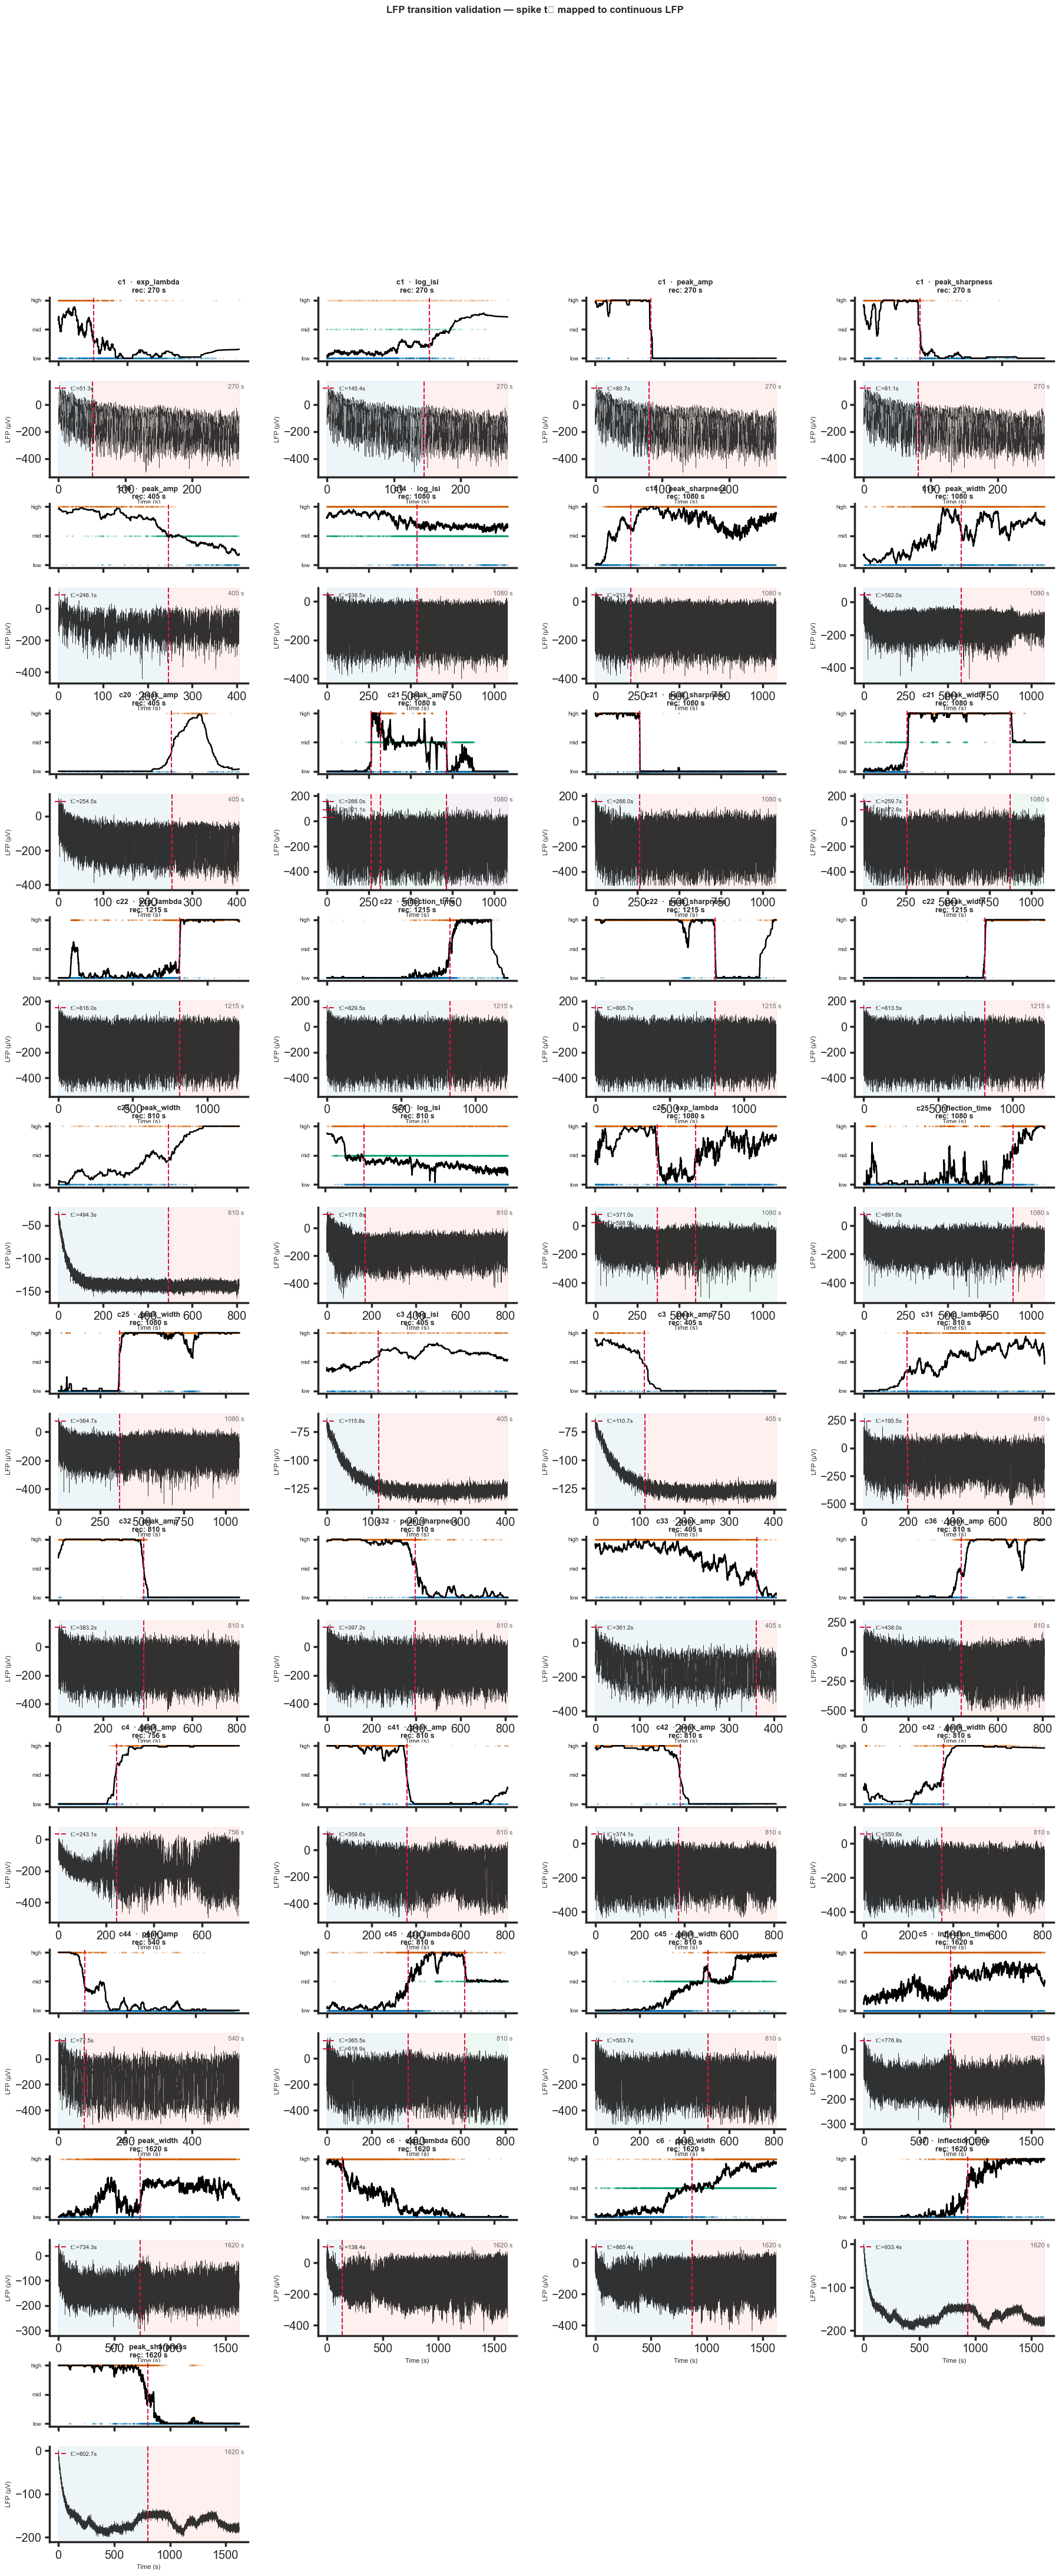

In [ ]:
# Validation: confirm transition time → LFP sample alignment
plot_lfp_transition_validation(
    df_transitions,
    lfp_npy_dir,
    cluster_pickle_dir,
    fs=2500,
    rolling_n=50,
    n_cols=4,
)


  specparam refit failed [c1|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c1|exp_lambda]: module 'numpy' has no attribute 'trapz'


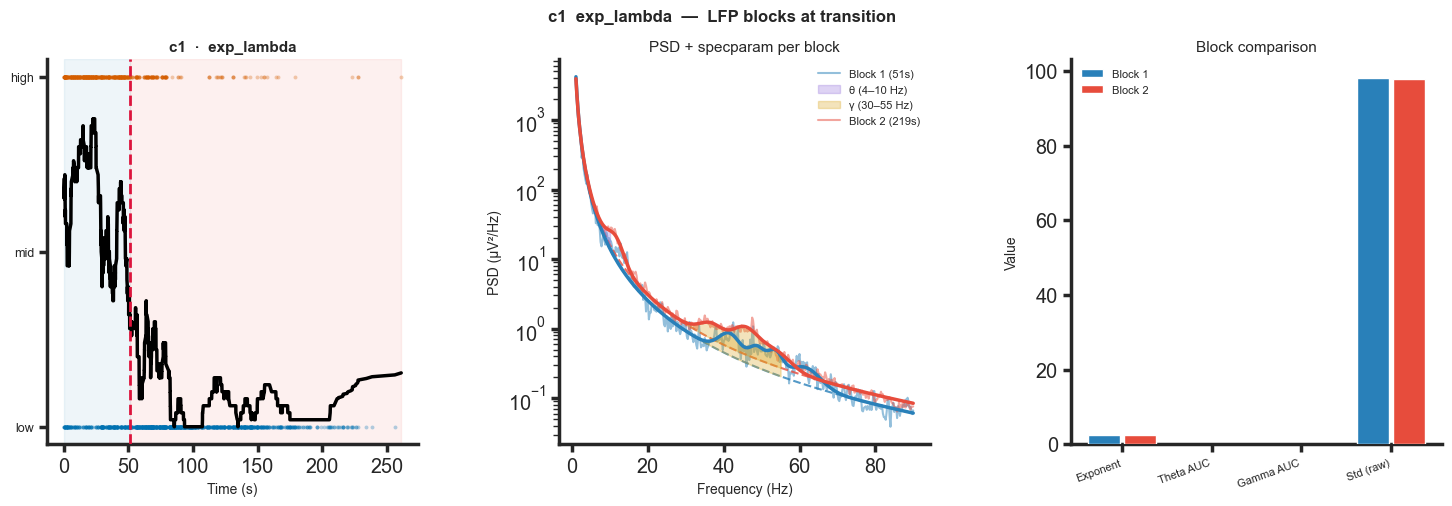

  specparam refit failed [c1|log_isi]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c1|log_isi]: module 'numpy' has no attribute 'trapz'


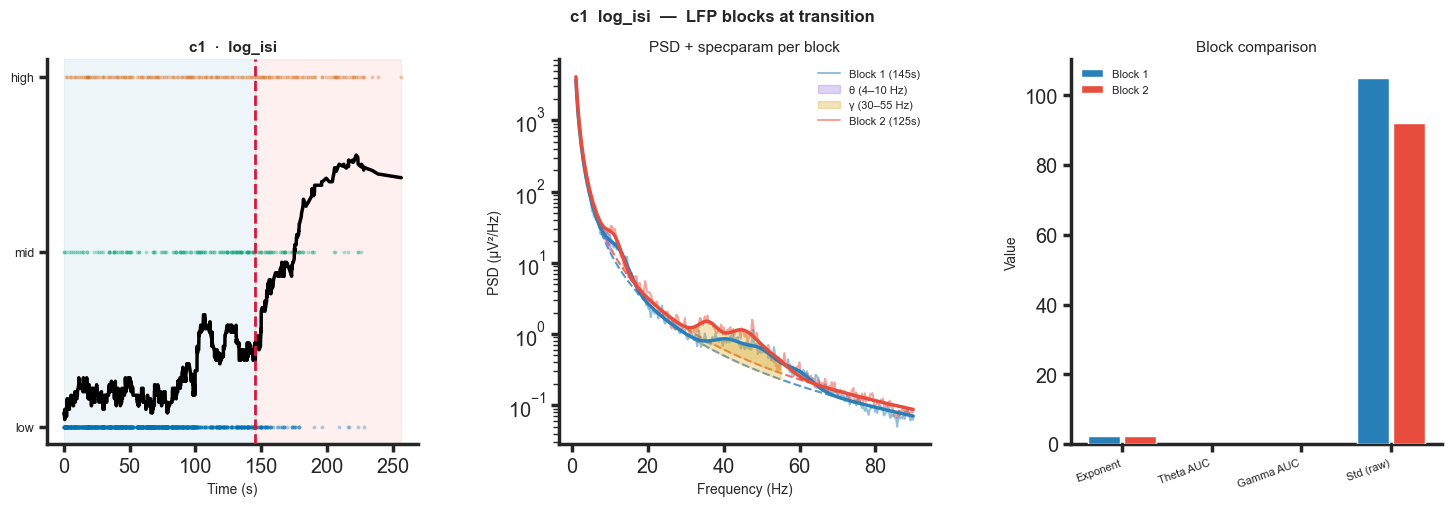

  specparam refit failed [c1|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c1|peak_amp]: module 'numpy' has no attribute 'trapz'


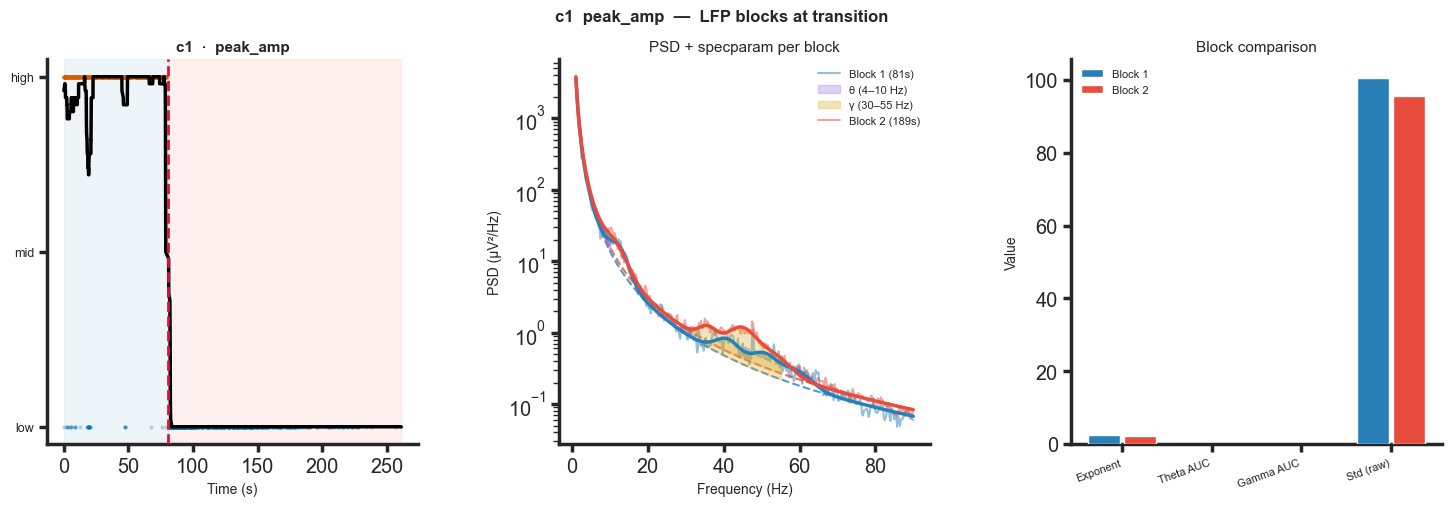

  specparam refit failed [c1|peak_sharpness]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c1|peak_sharpness]: module 'numpy' has no attribute 'trapz'


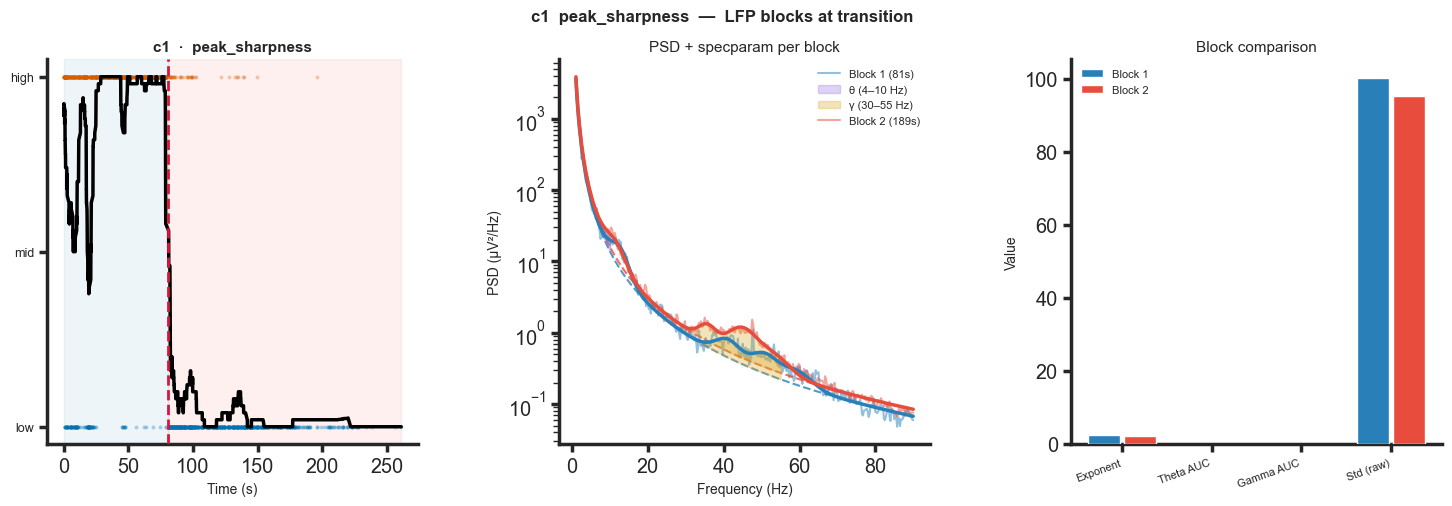

  specparam refit failed [c10|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c10|peak_amp]: module 'numpy' has no attribute 'trapz'


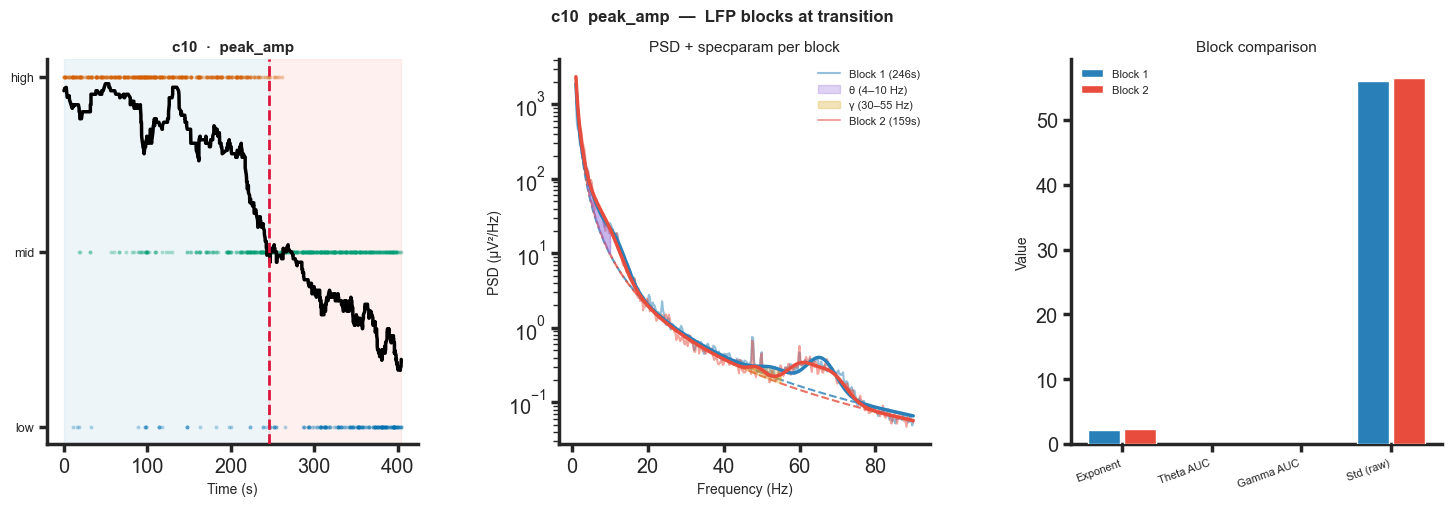

  specparam refit failed [c14|log_isi]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c14|log_isi]: module 'numpy' has no attribute 'trapz'


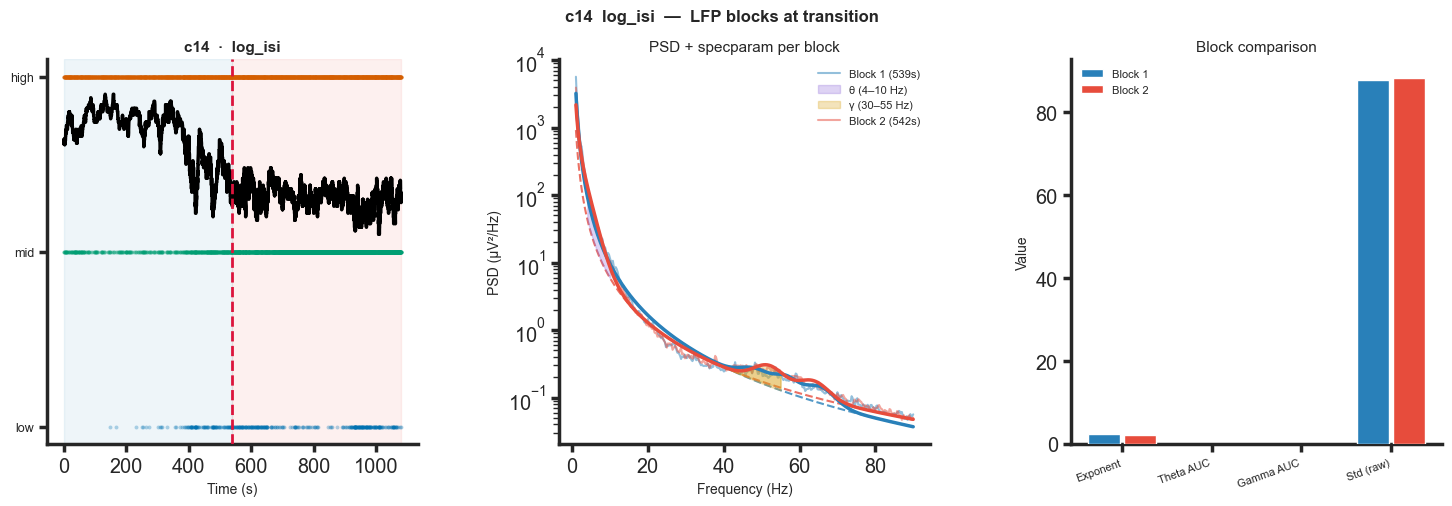

  specparam refit failed [c14|peak_sharpness]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c14|peak_sharpness]: module 'numpy' has no attribute 'trapz'


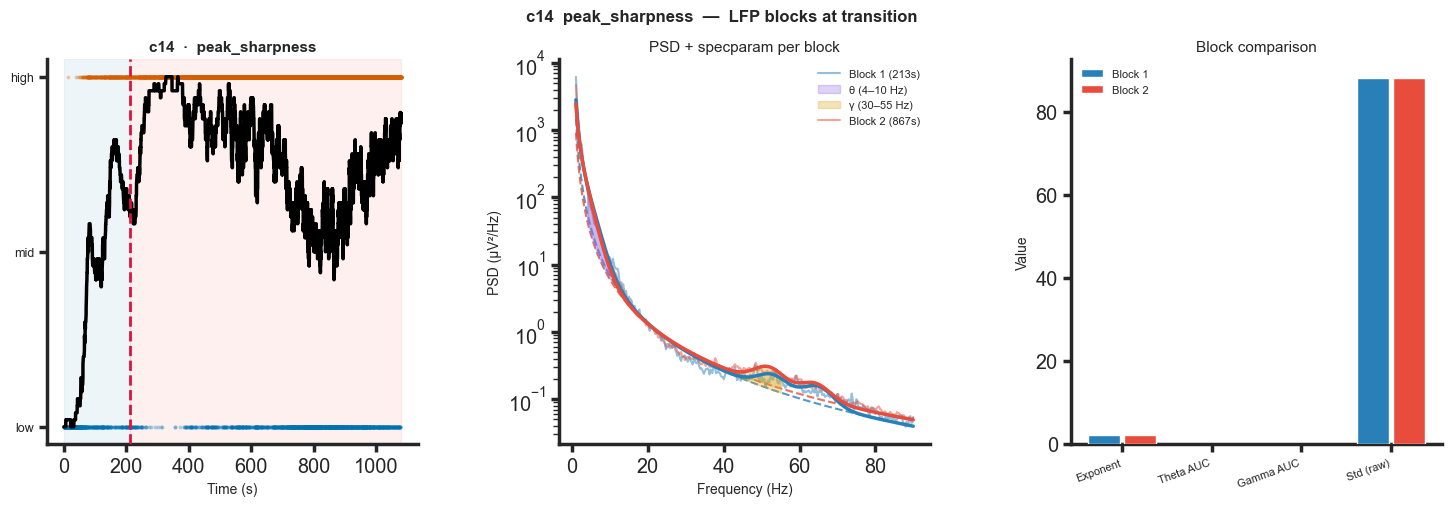

  specparam refit failed [c15|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c15|peak_width]: module 'numpy' has no attribute 'trapz'


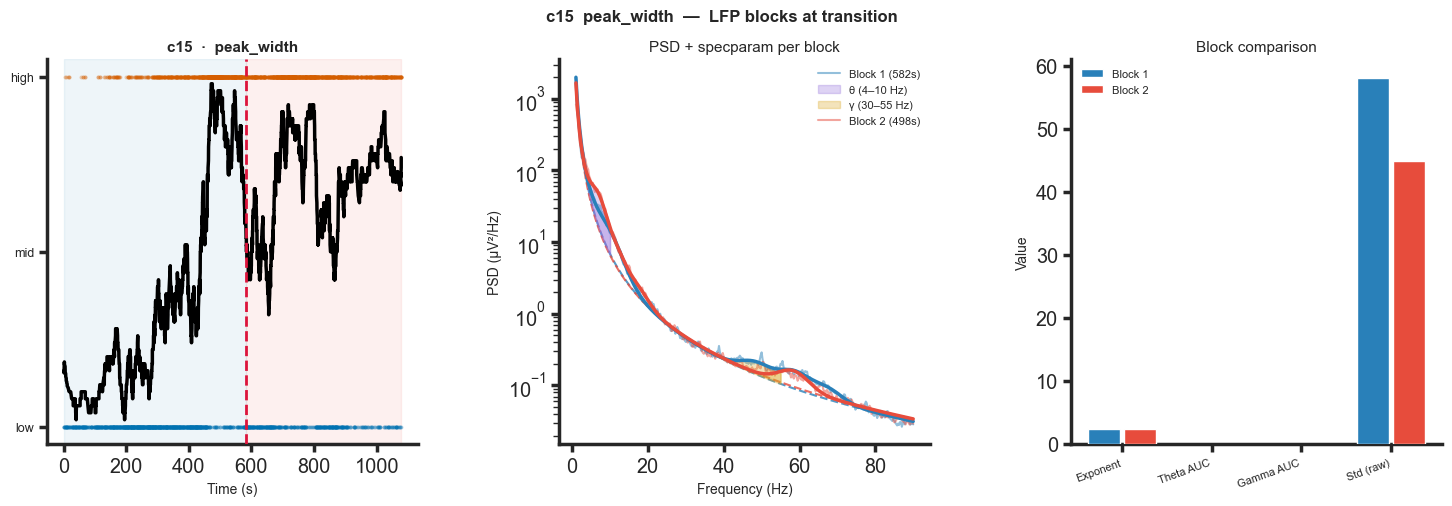

  specparam refit failed [c20|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c20|peak_amp]: module 'numpy' has no attribute 'trapz'


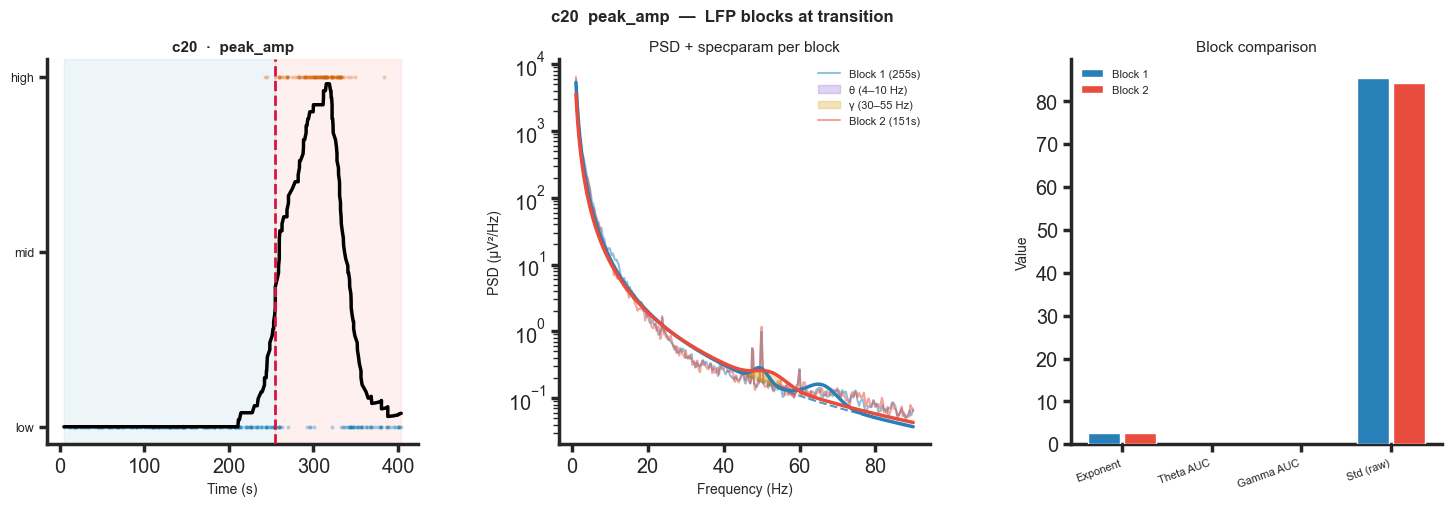

  specparam refit failed [c21|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c21|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c21|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c21|peak_amp]: module 'numpy' has no attribute 'trapz'


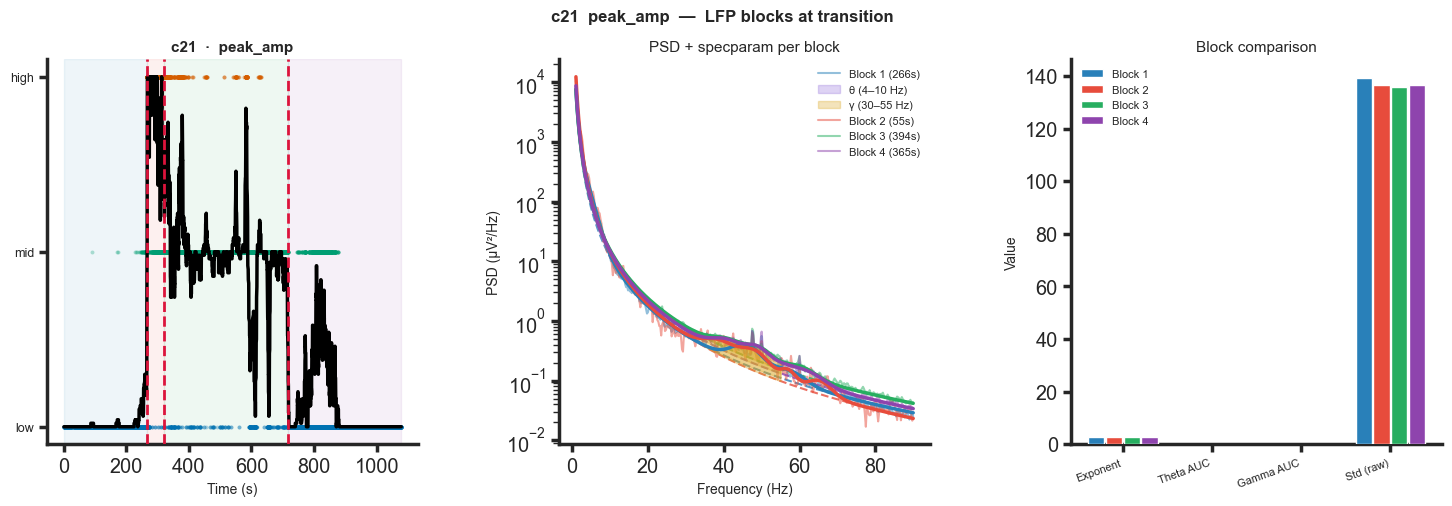

  specparam refit failed [c21|peak_sharpness]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c21|peak_sharpness]: module 'numpy' has no attribute 'trapz'


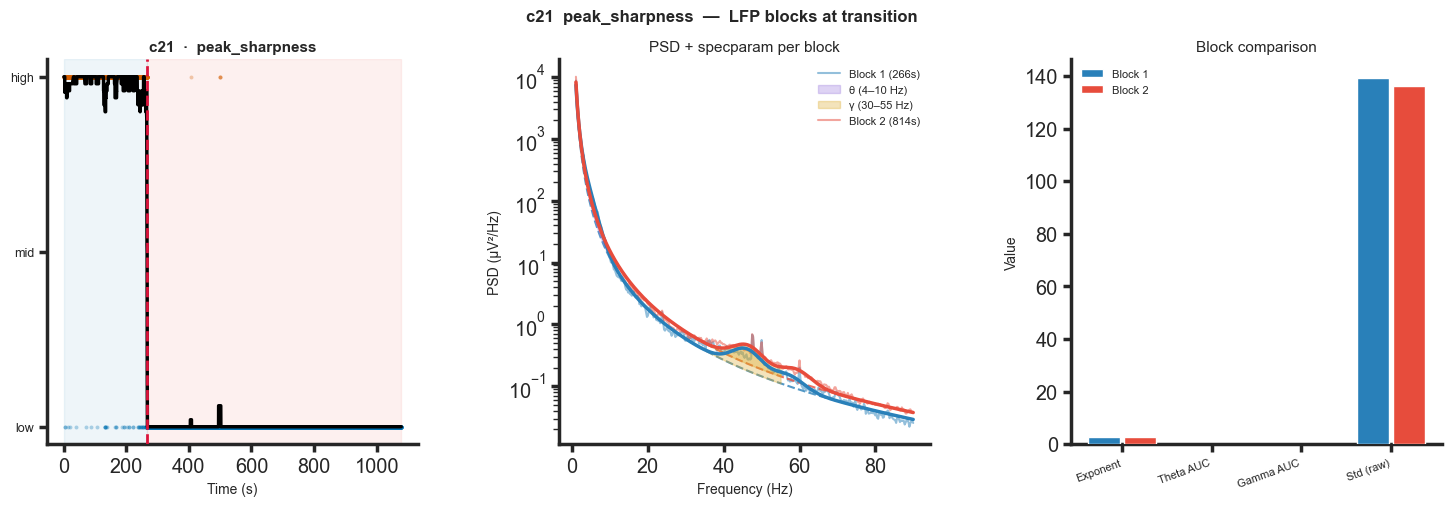

  specparam refit failed [c21|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c21|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c21|peak_width]: module 'numpy' has no attribute 'trapz'


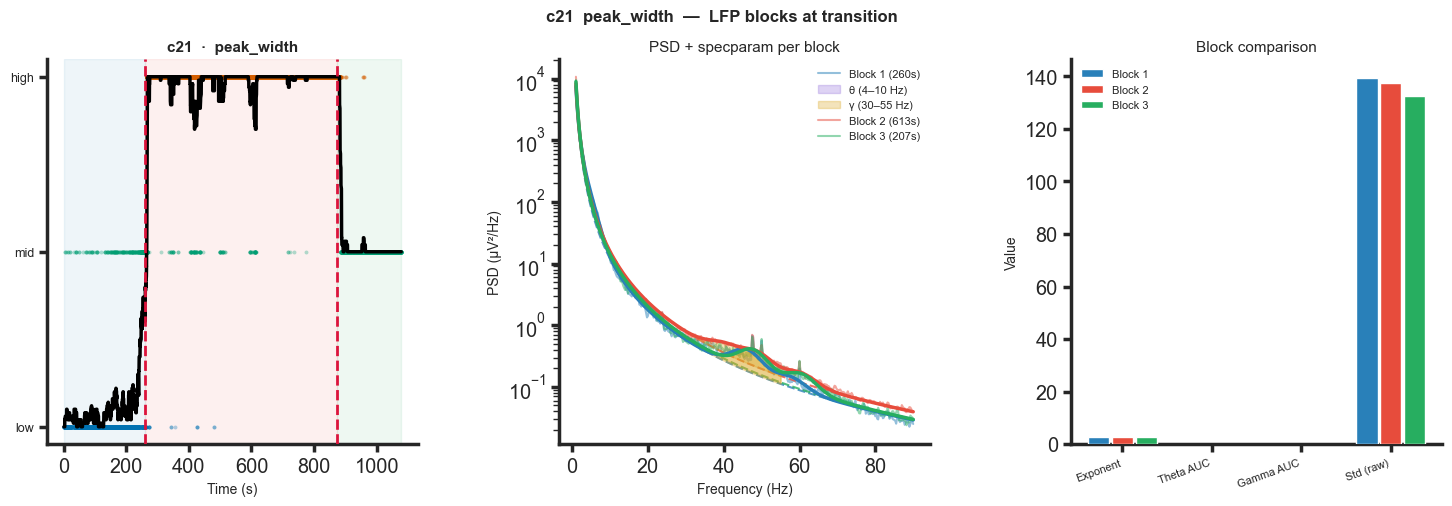

  specparam refit failed [c22|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c22|exp_lambda]: module 'numpy' has no attribute 'trapz'


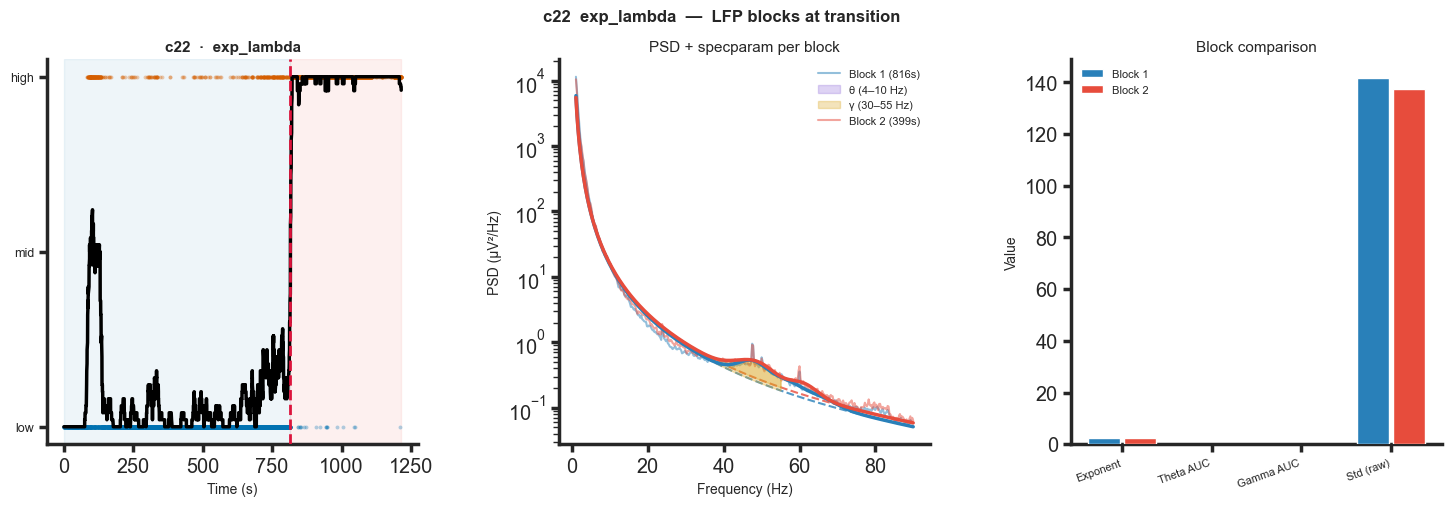

  specparam refit failed [c22|inflection_time]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c22|inflection_time]: module 'numpy' has no attribute 'trapz'


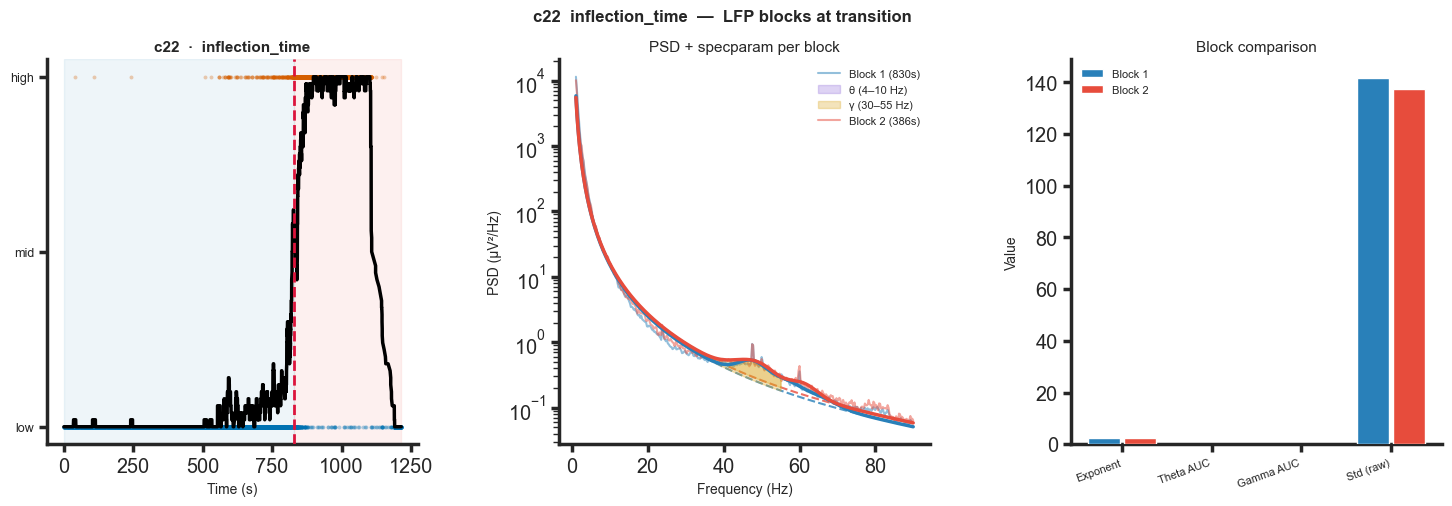

  specparam refit failed [c22|peak_sharpness]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c22|peak_sharpness]: module 'numpy' has no attribute 'trapz'


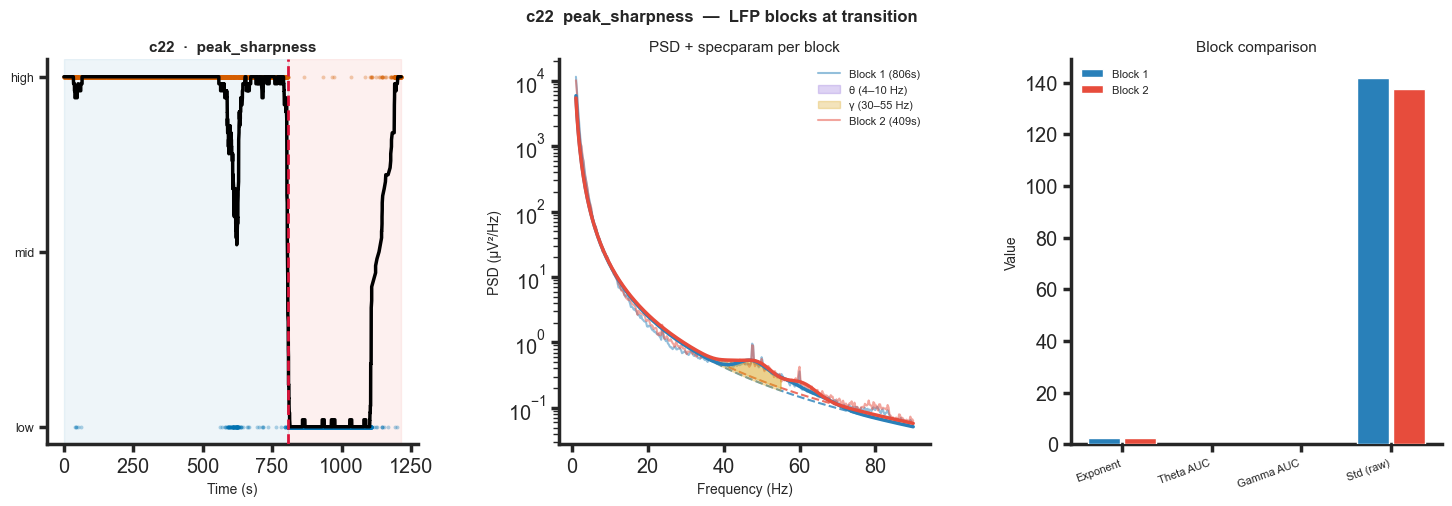

  specparam refit failed [c22|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c22|peak_width]: module 'numpy' has no attribute 'trapz'


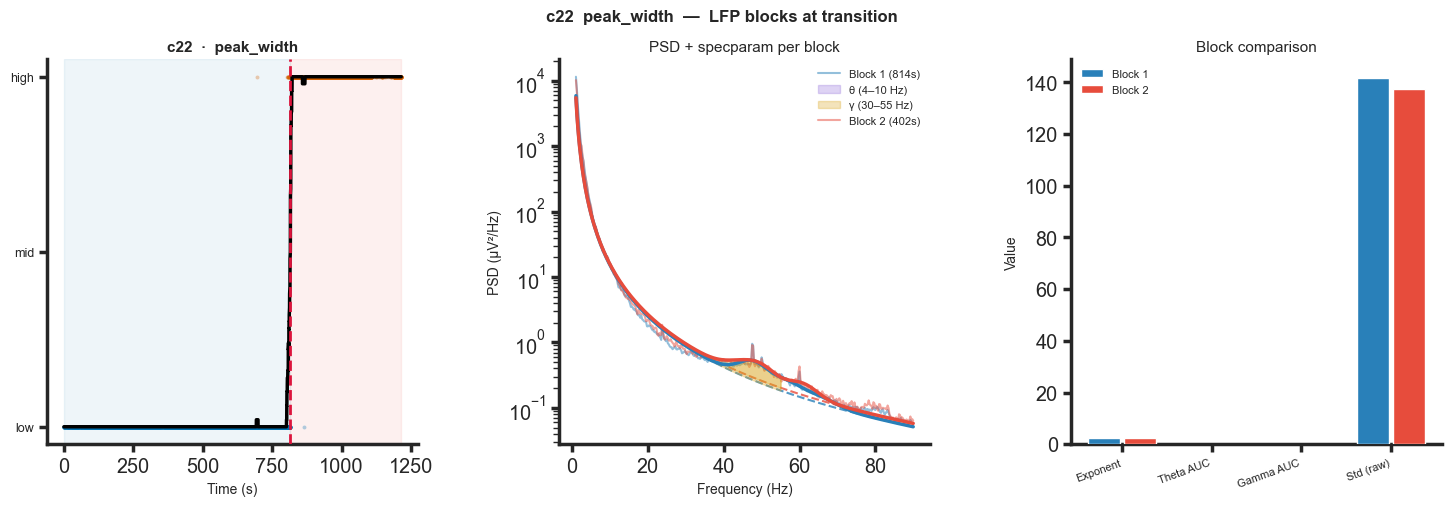

  specparam refit failed [c23|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c23|peak_width]: module 'numpy' has no attribute 'trapz'


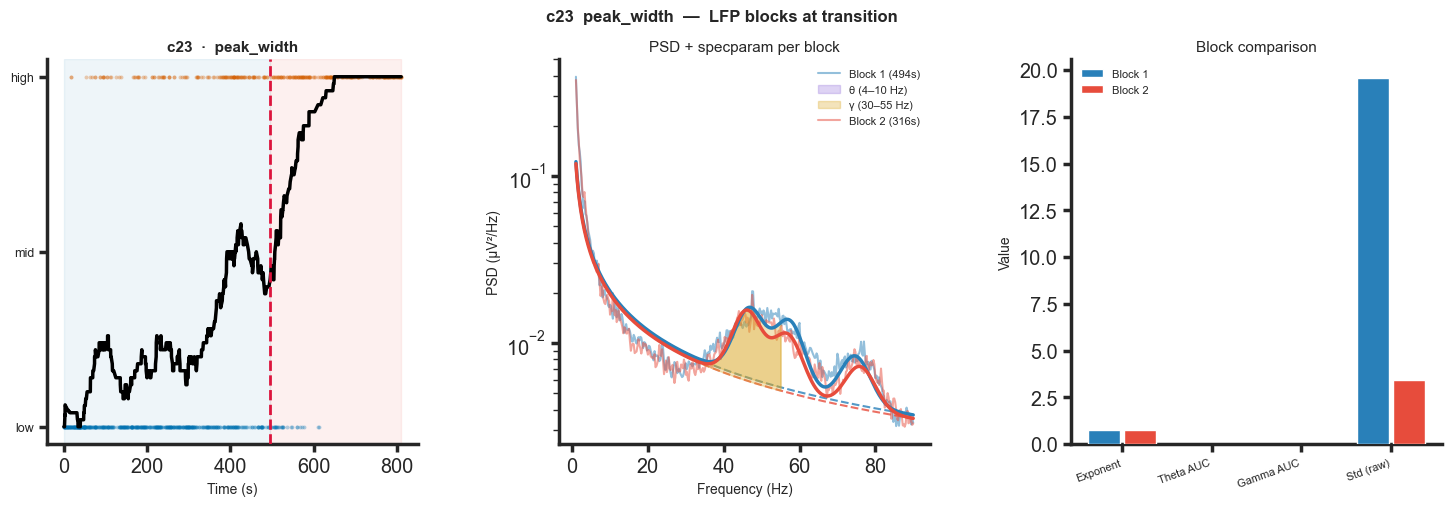

  specparam refit failed [c24|log_isi]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c24|log_isi]: module 'numpy' has no attribute 'trapz'


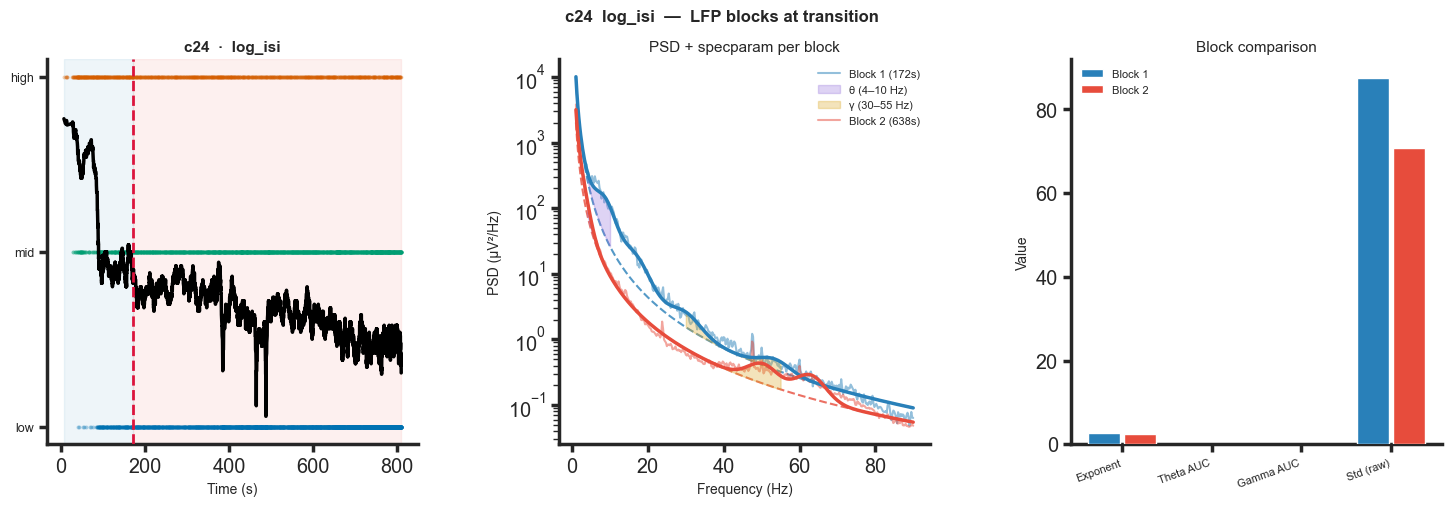

  specparam refit failed [c25|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c25|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c25|exp_lambda]: module 'numpy' has no attribute 'trapz'


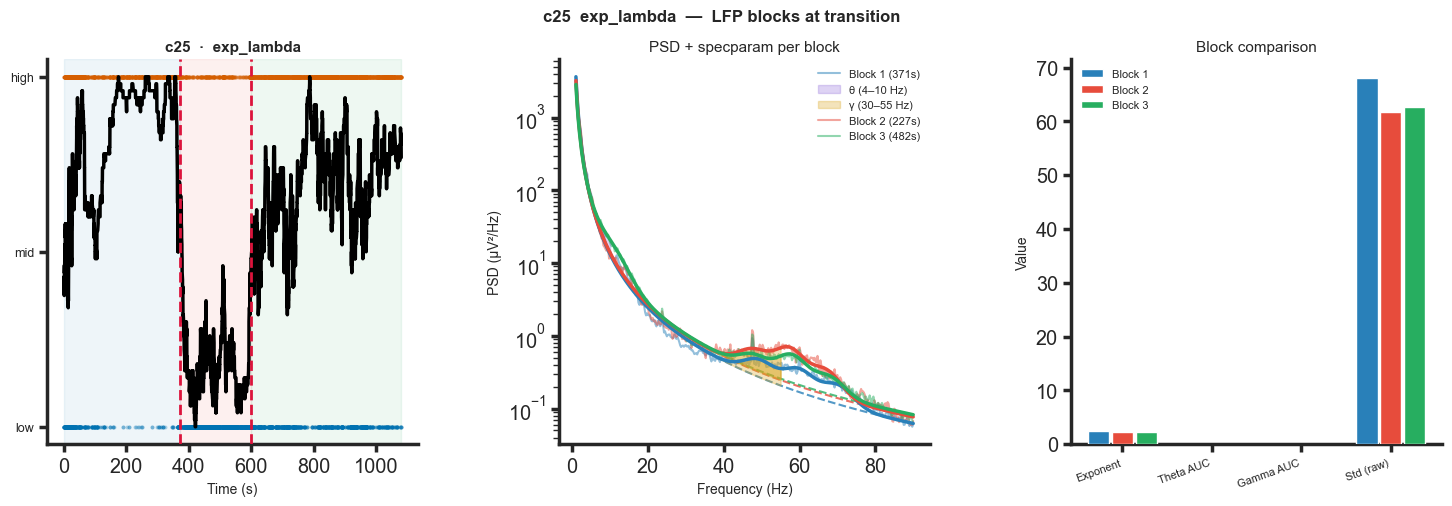

  specparam refit failed [c25|inflection_time]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c25|inflection_time]: module 'numpy' has no attribute 'trapz'


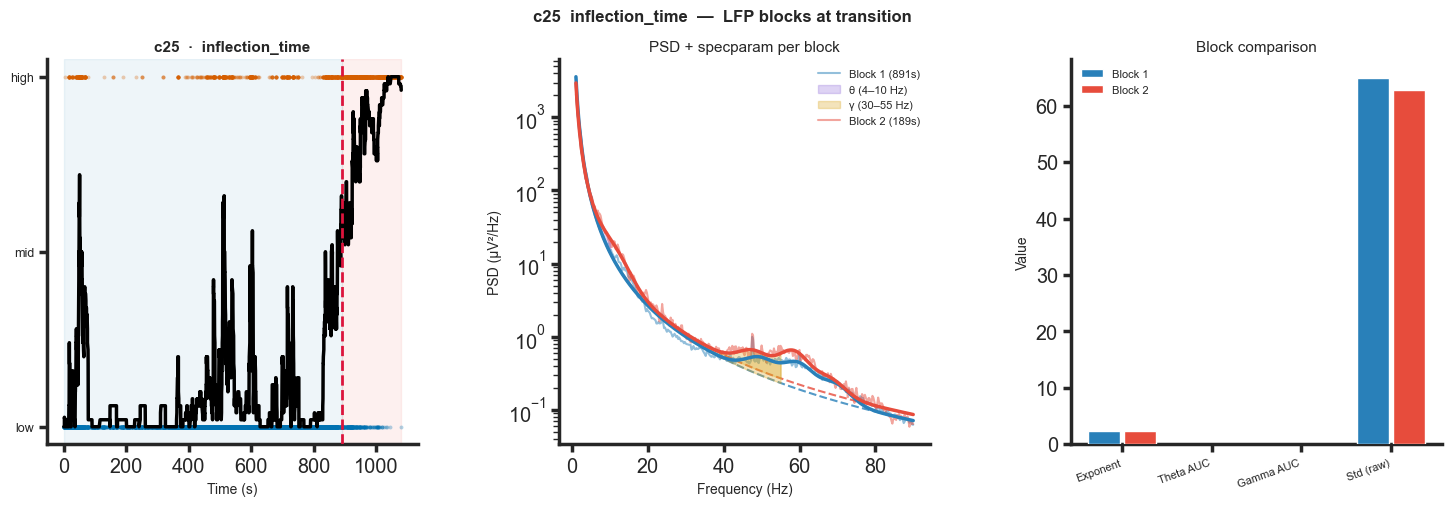

  specparam refit failed [c25|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c25|peak_width]: module 'numpy' has no attribute 'trapz'


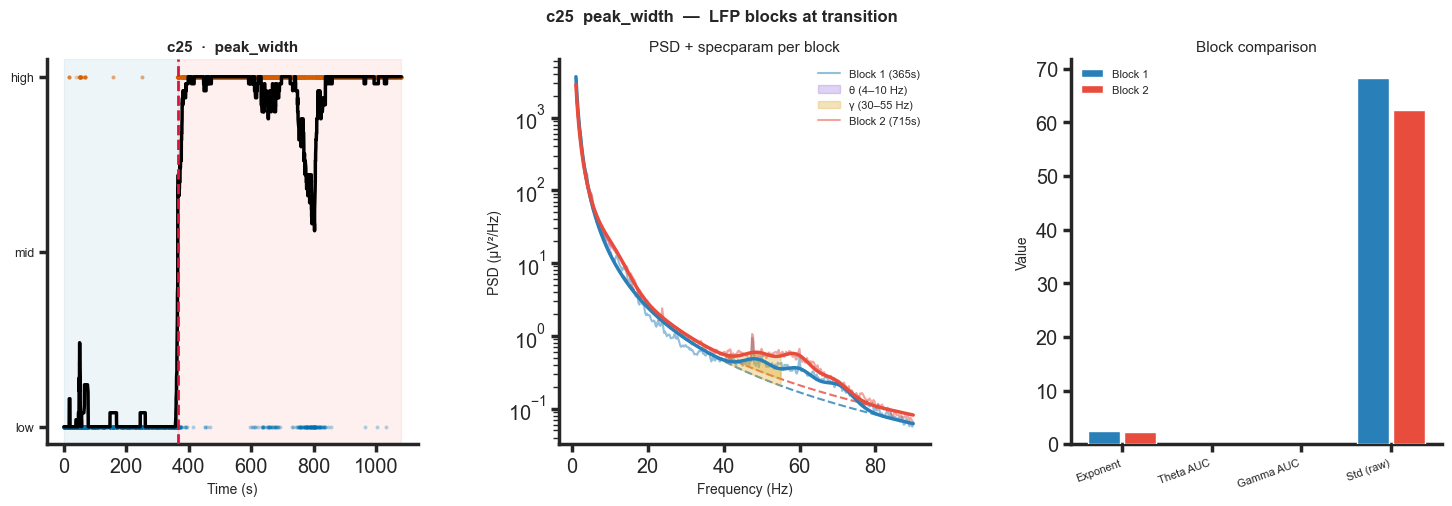

  specparam refit failed [c3|log_isi]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c3|log_isi]: module 'numpy' has no attribute 'trapz'


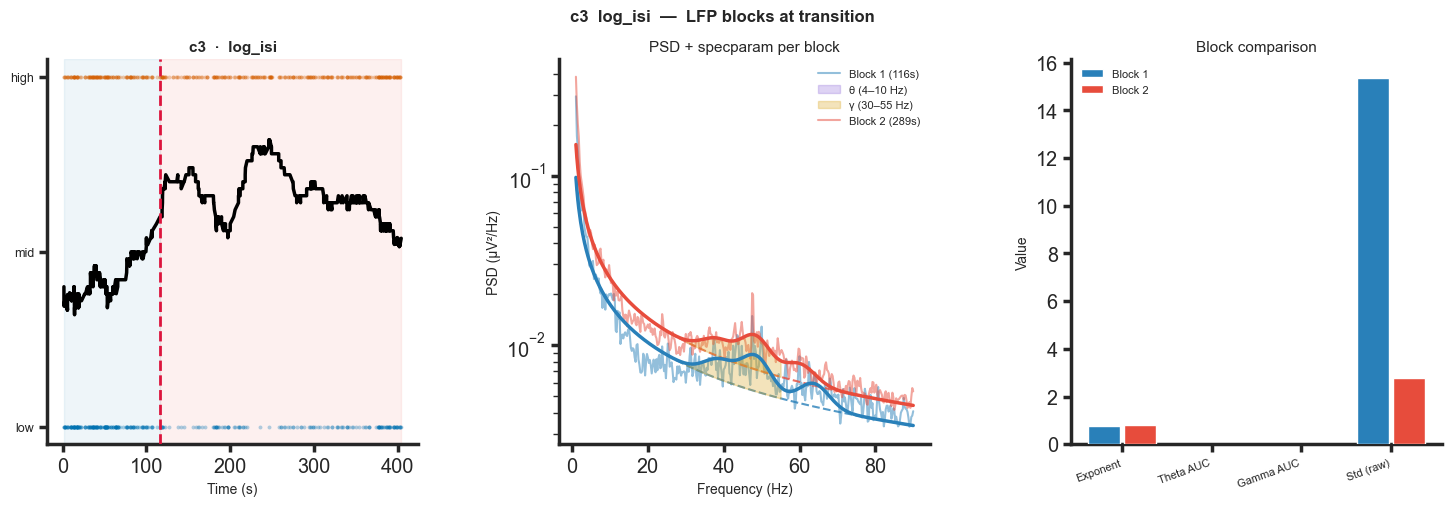

  specparam refit failed [c3|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c3|peak_amp]: module 'numpy' has no attribute 'trapz'


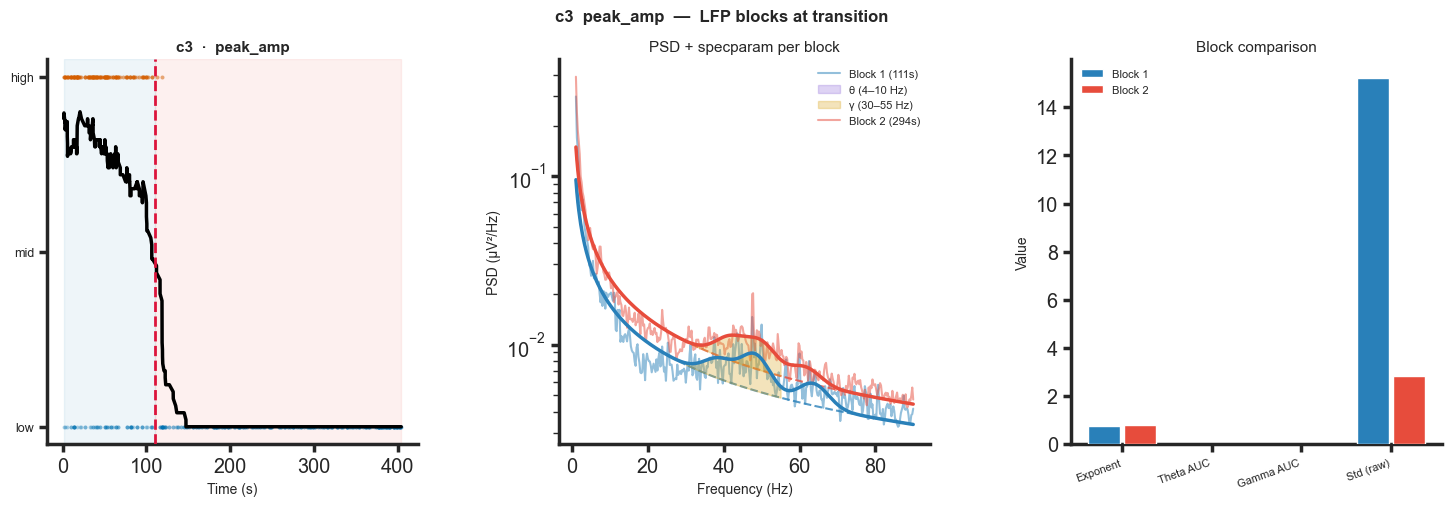

  specparam refit failed [c31|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c31|exp_lambda]: module 'numpy' has no attribute 'trapz'


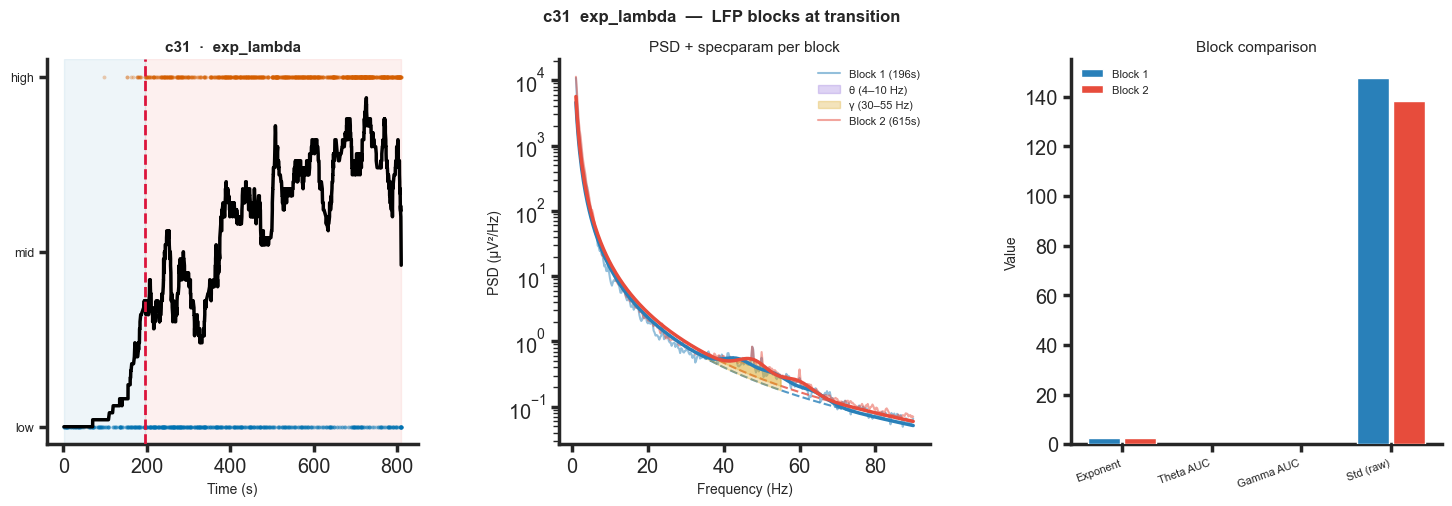

  specparam refit failed [c32|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c32|peak_amp]: module 'numpy' has no attribute 'trapz'


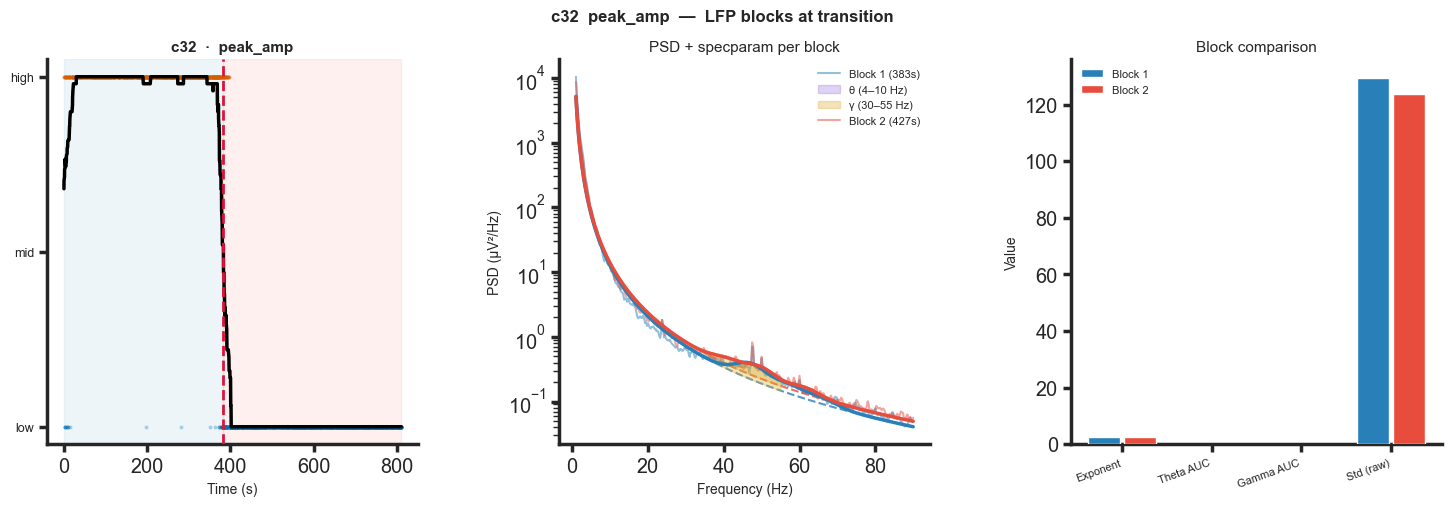

  specparam refit failed [c32|peak_sharpness]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c32|peak_sharpness]: module 'numpy' has no attribute 'trapz'


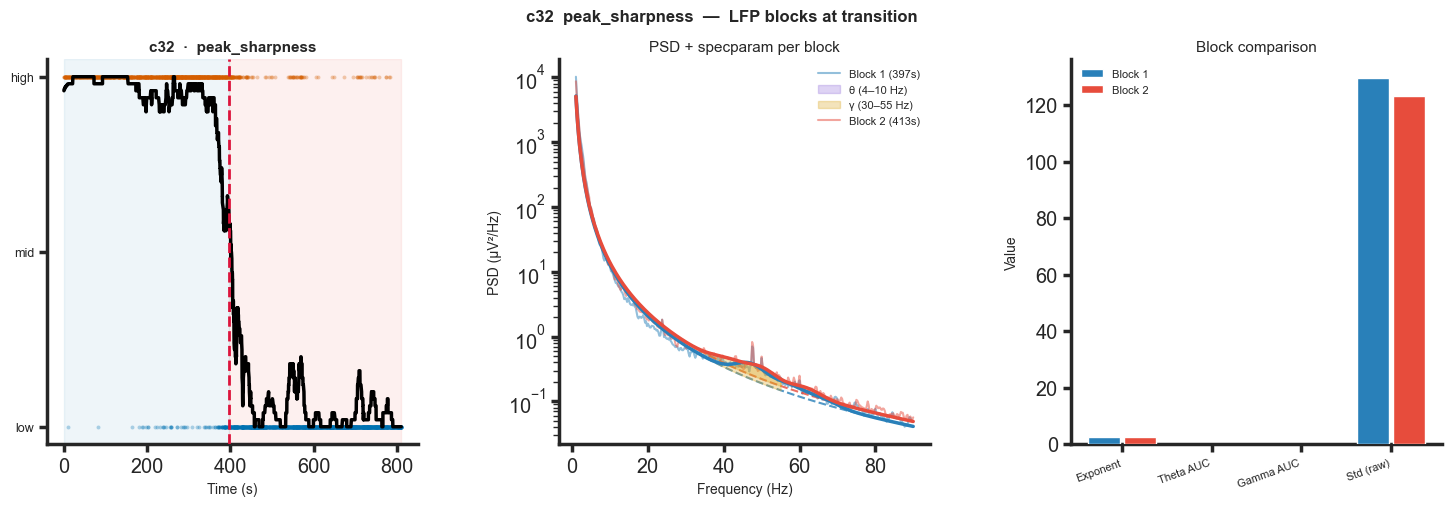

  specparam refit failed [c33|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c33|peak_amp]: module 'numpy' has no attribute 'trapz'


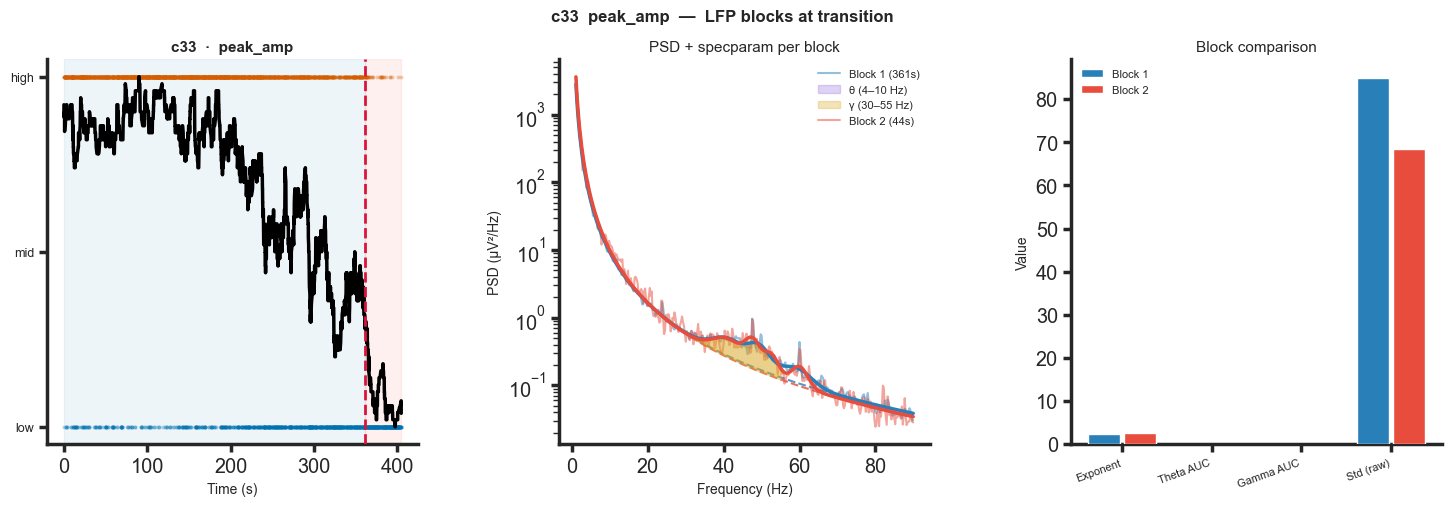

  specparam refit failed [c36|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c36|peak_amp]: module 'numpy' has no attribute 'trapz'


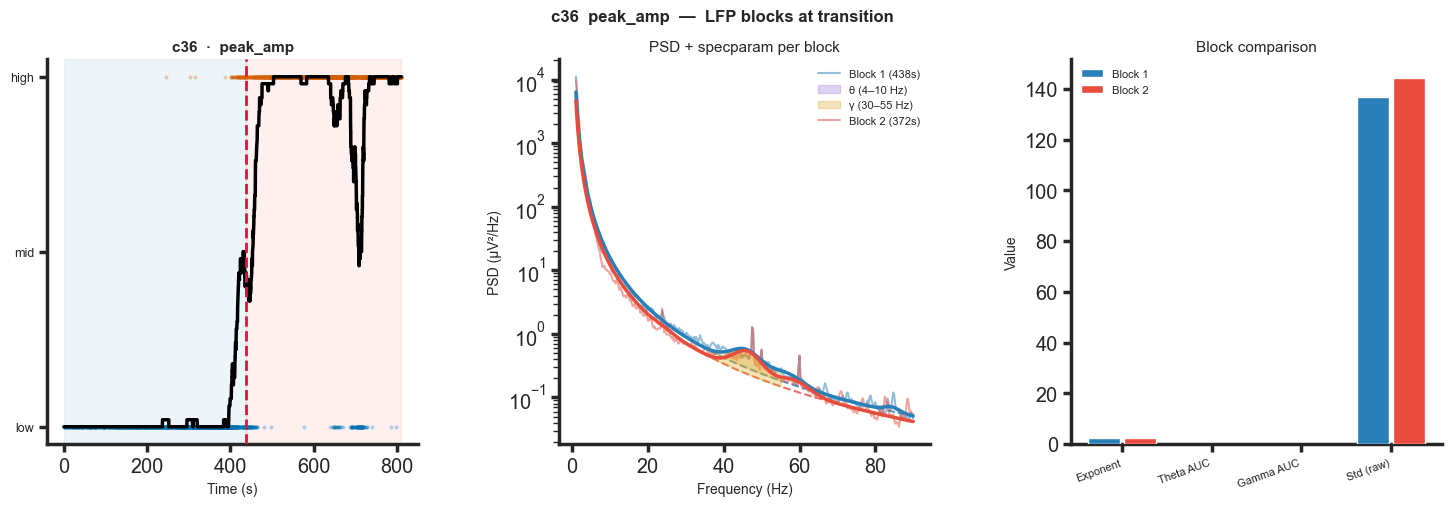

  specparam refit failed [c4|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c4|peak_amp]: module 'numpy' has no attribute 'trapz'


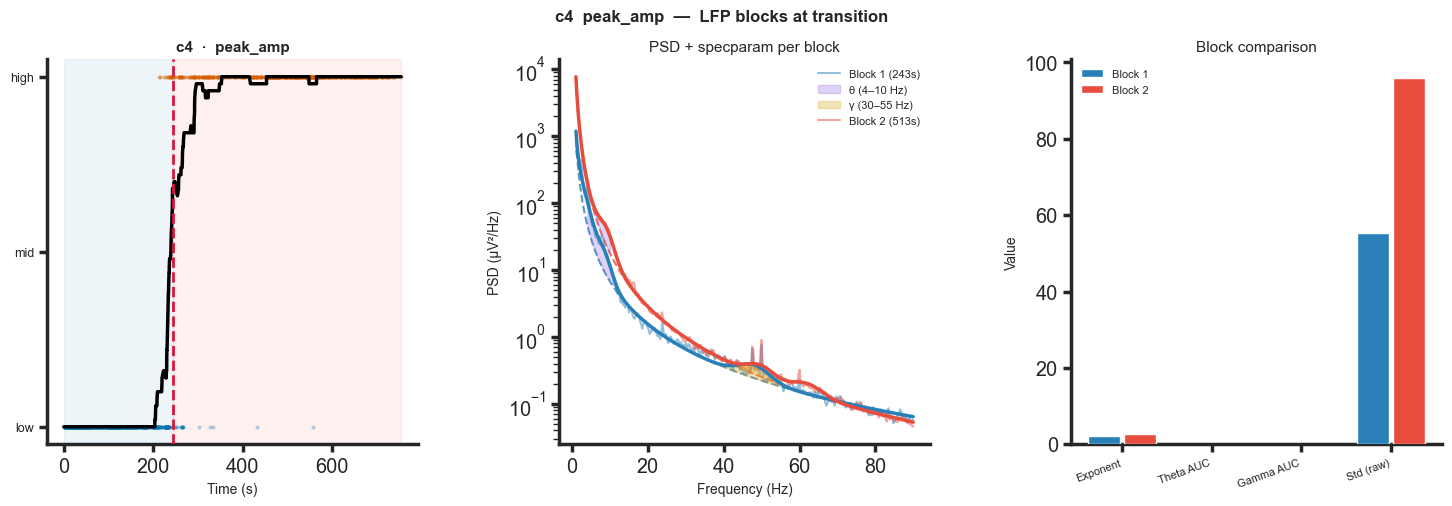

  specparam refit failed [c41|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c41|peak_amp]: module 'numpy' has no attribute 'trapz'


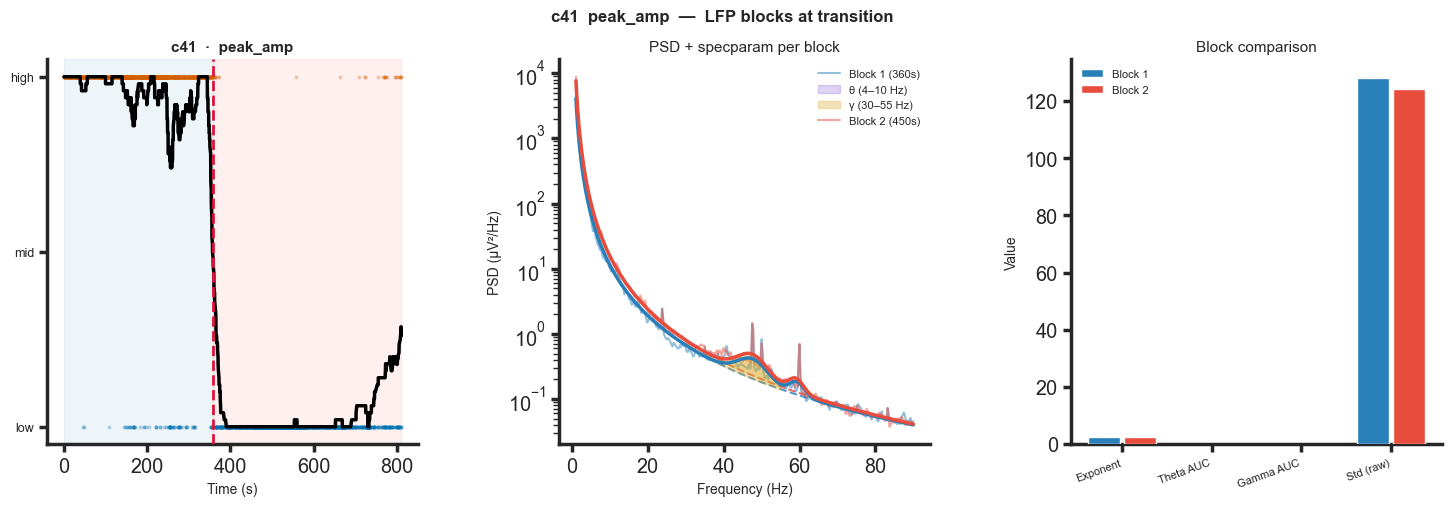

  specparam refit failed [c42|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c42|peak_amp]: module 'numpy' has no attribute 'trapz'


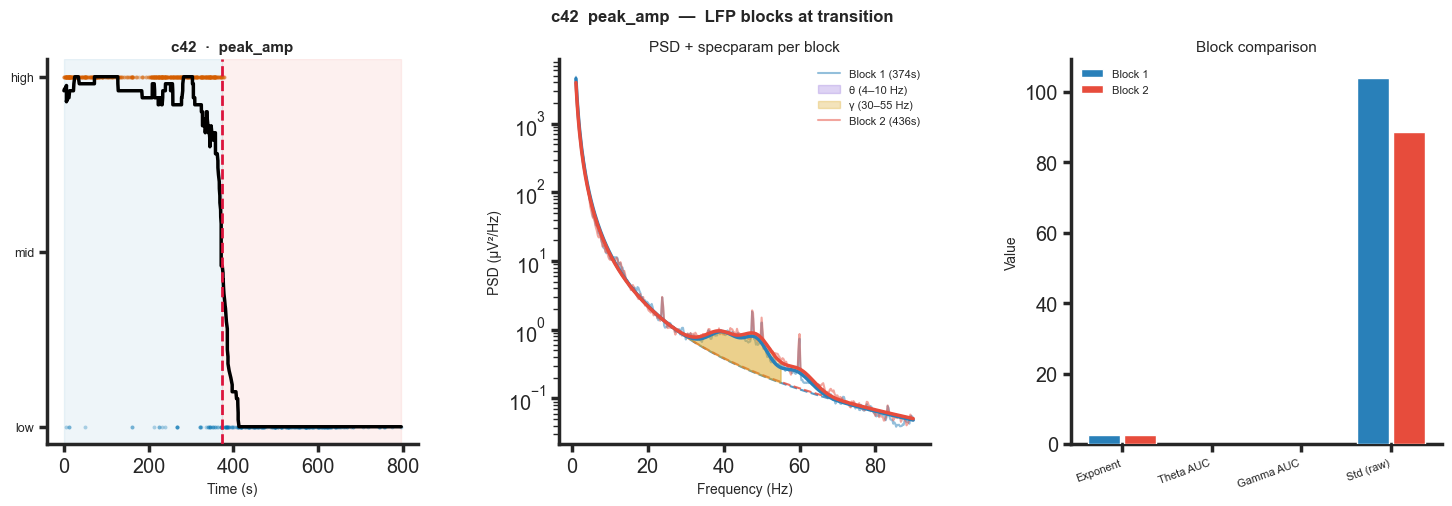

  specparam refit failed [c42|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c42|peak_width]: module 'numpy' has no attribute 'trapz'


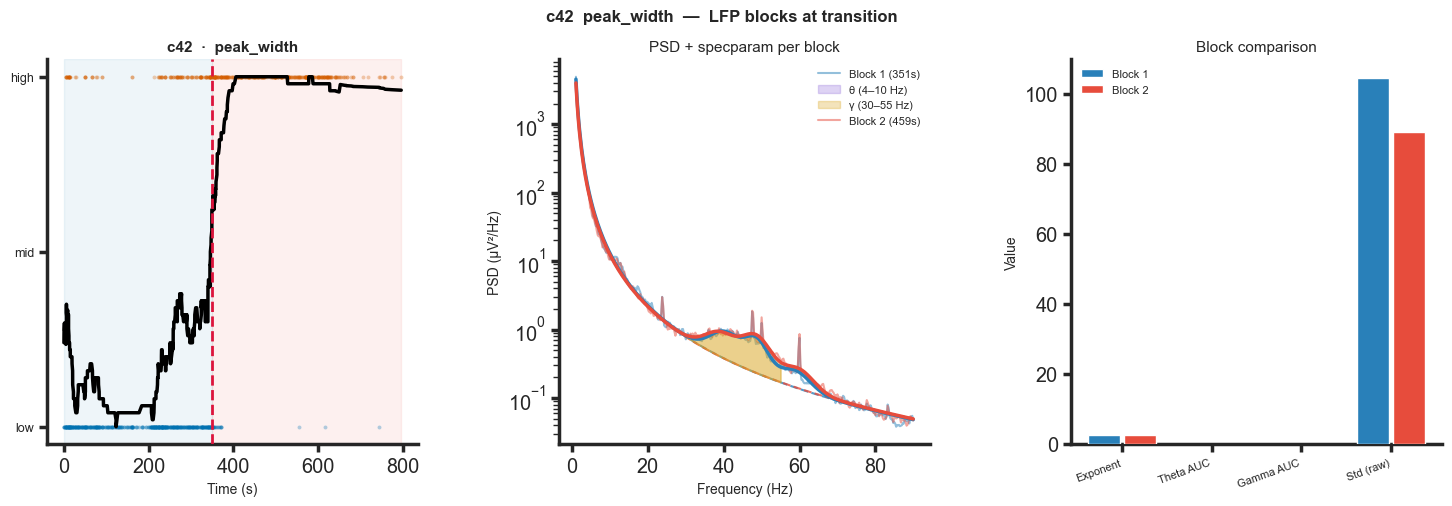

  specparam refit failed [c44|peak_amp]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c44|peak_amp]: module 'numpy' has no attribute 'trapz'


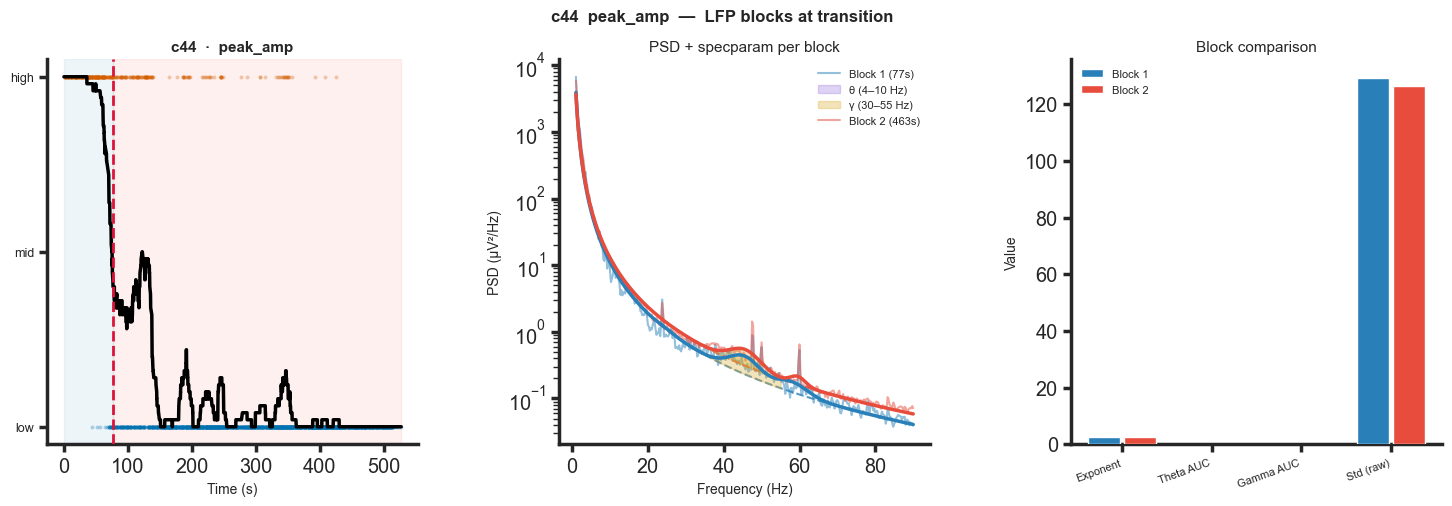

  specparam refit failed [c45|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c45|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c45|exp_lambda]: module 'numpy' has no attribute 'trapz'


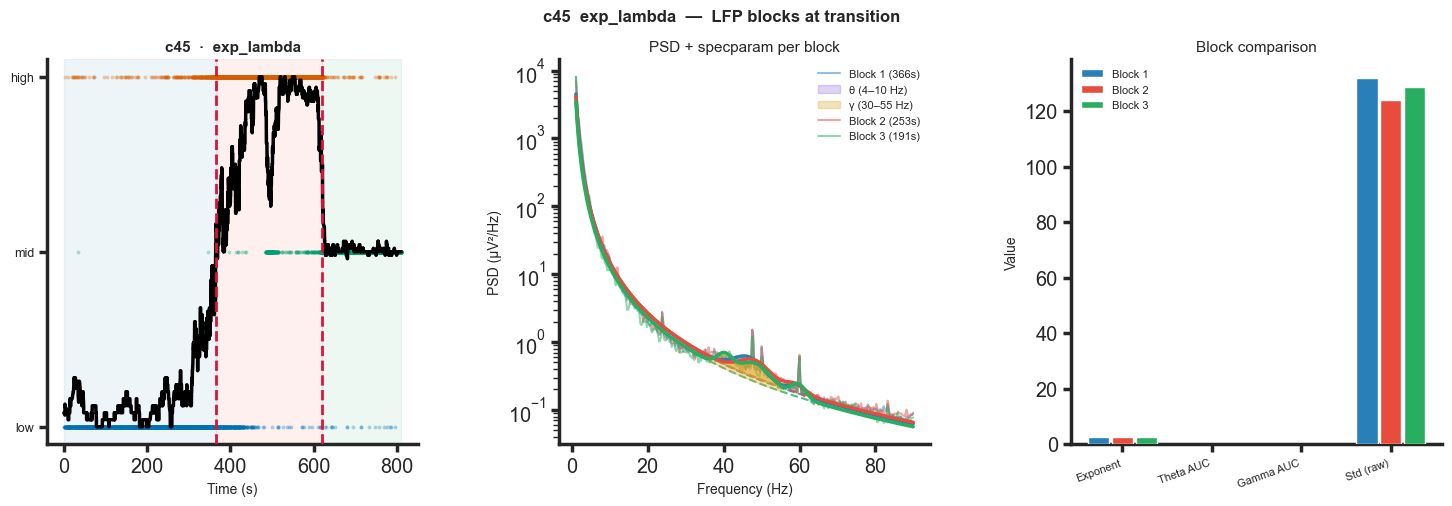

  specparam refit failed [c45|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c45|peak_width]: module 'numpy' has no attribute 'trapz'


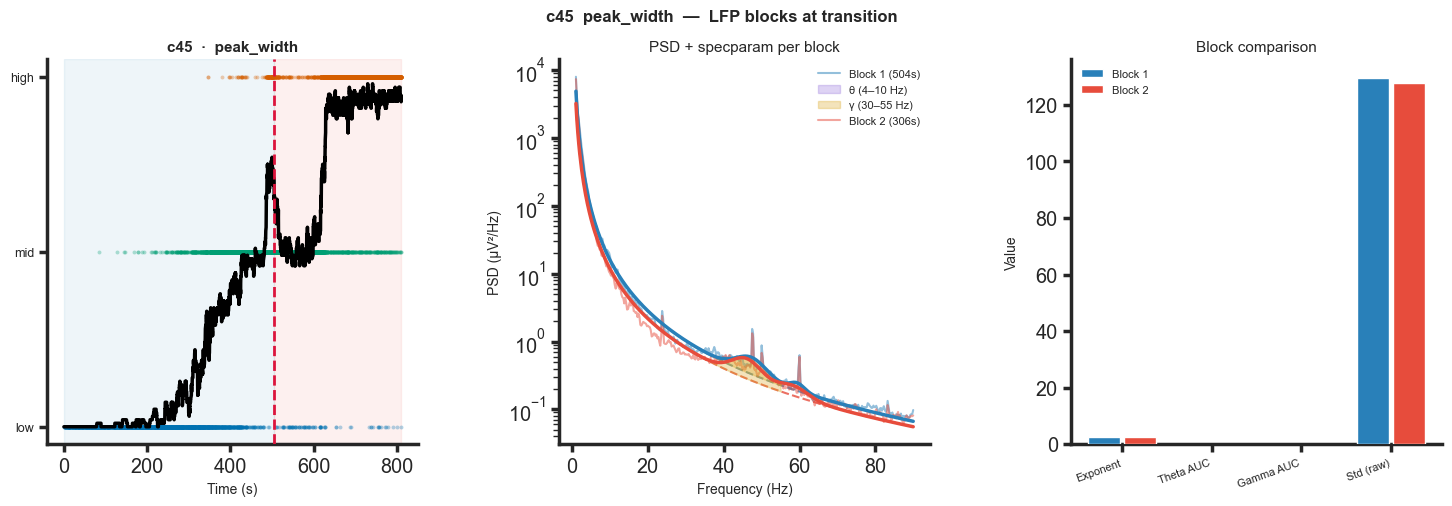

  specparam refit failed [c5|inflection_time]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c5|inflection_time]: module 'numpy' has no attribute 'trapz'


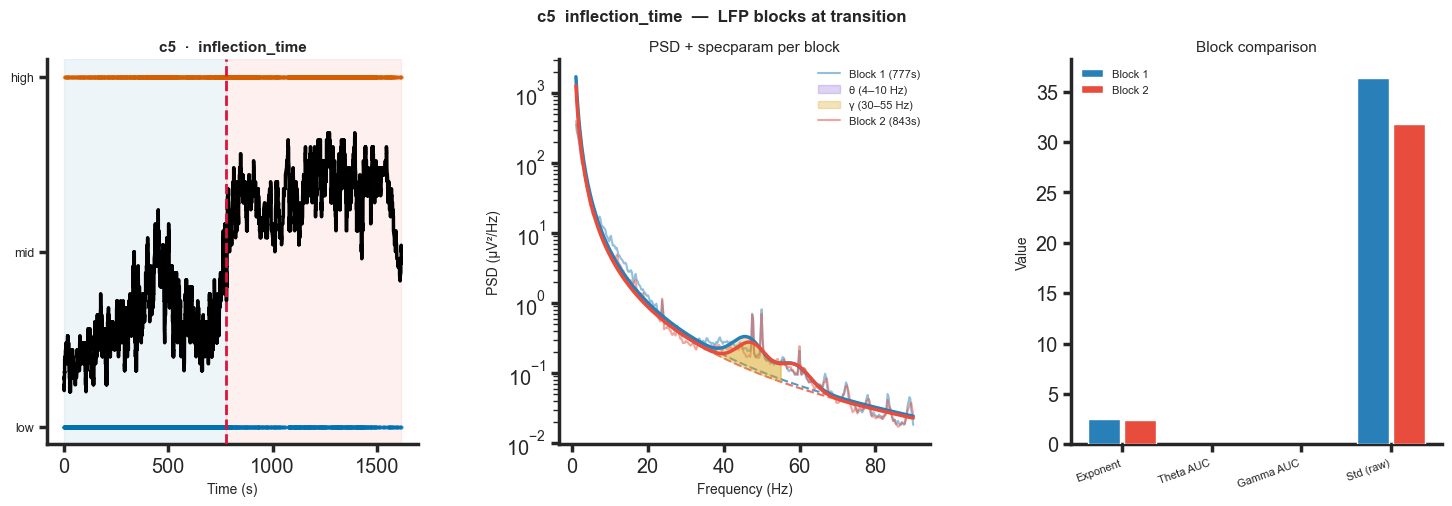

  specparam refit failed [c5|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c5|peak_width]: module 'numpy' has no attribute 'trapz'


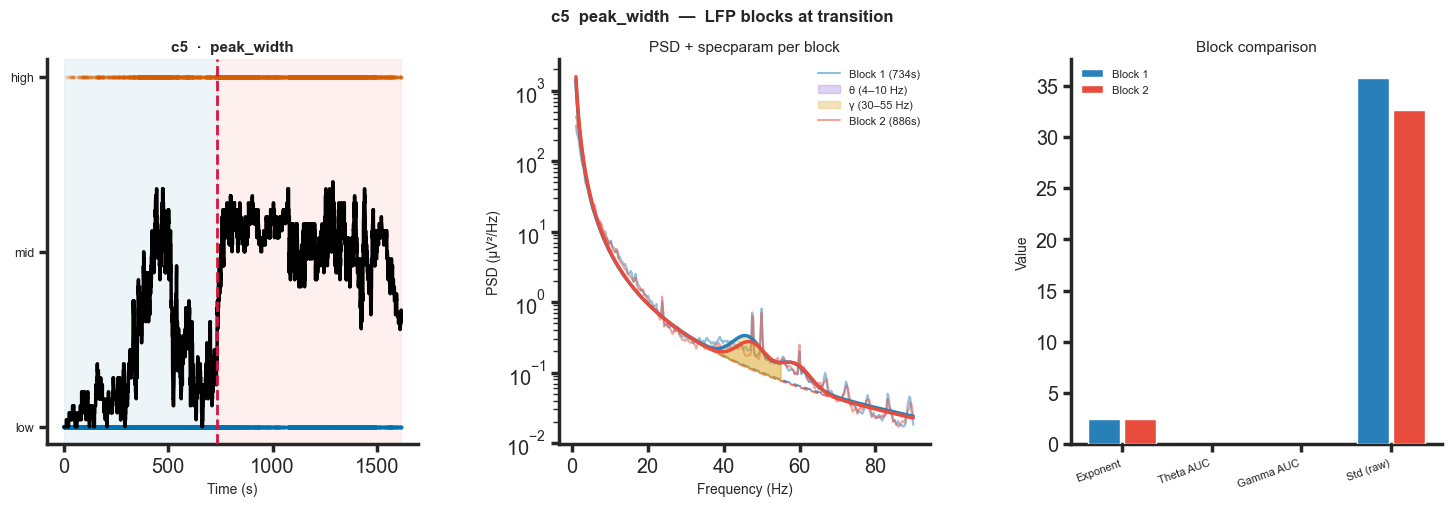

  specparam refit failed [c6|exp_lambda]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c6|exp_lambda]: module 'numpy' has no attribute 'trapz'


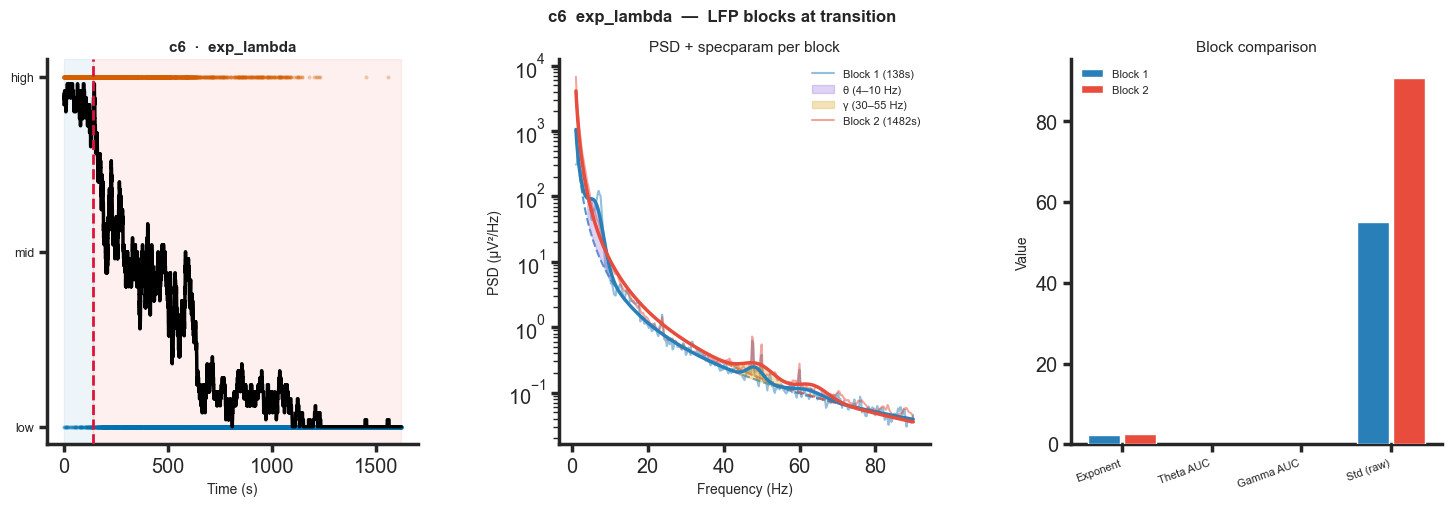

  specparam refit failed [c6|peak_width]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c6|peak_width]: module 'numpy' has no attribute 'trapz'


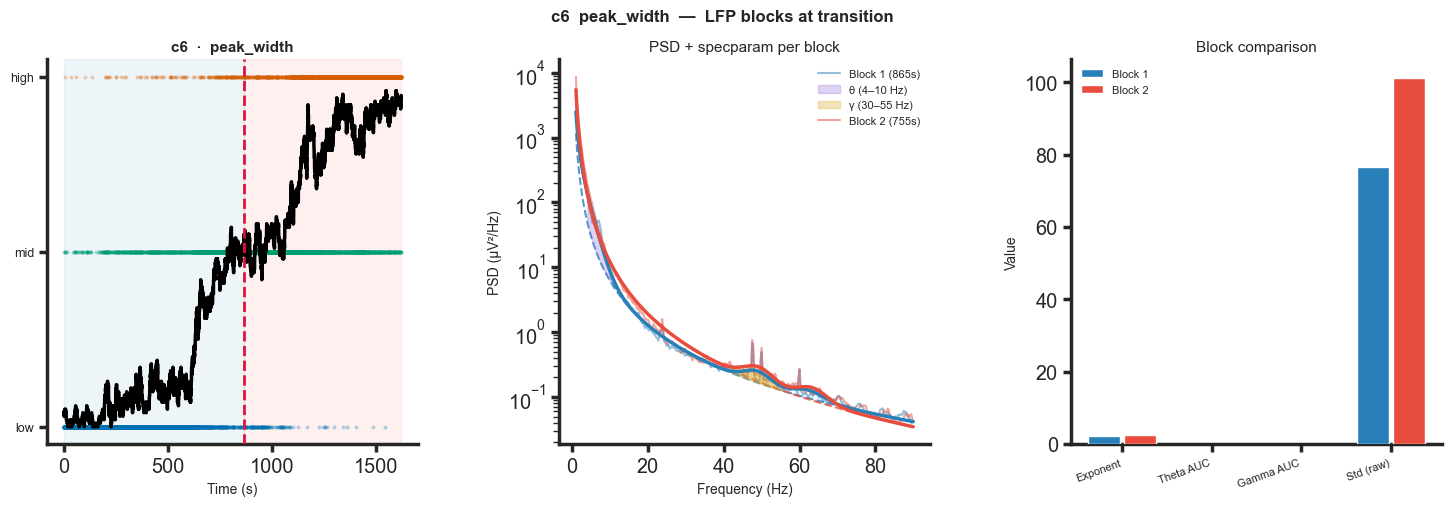

  specparam refit failed [c7|inflection_time]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c7|inflection_time]: module 'numpy' has no attribute 'trapz'


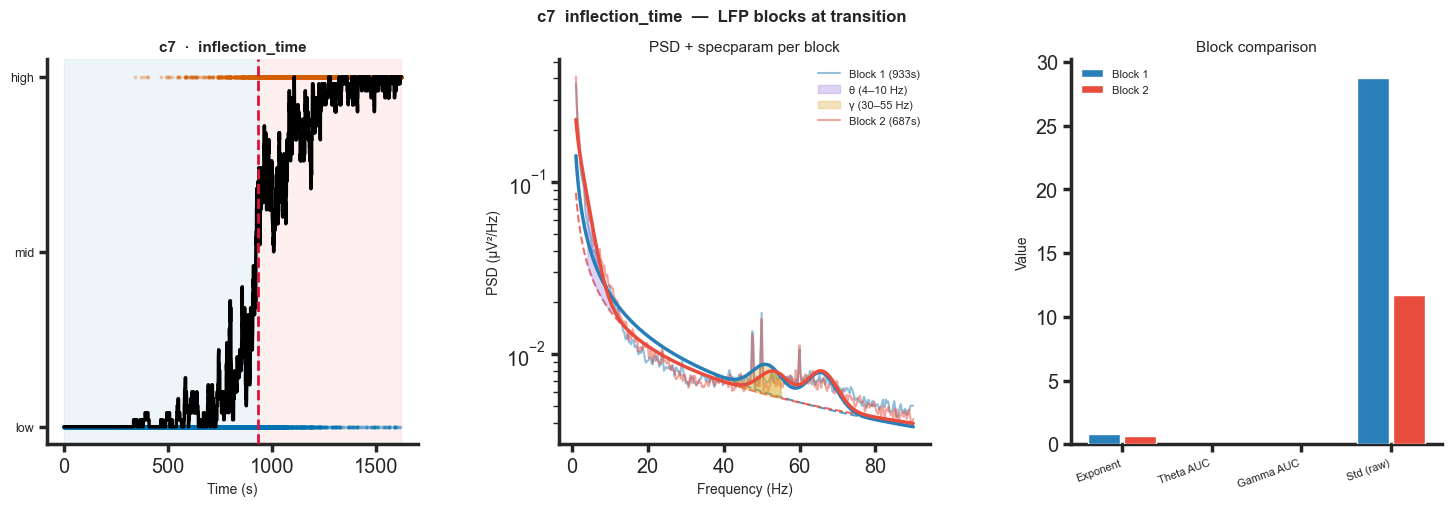

  specparam refit failed [c7|peak_sharpness]: module 'numpy' has no attribute 'trapz'
  specparam refit failed [c7|peak_sharpness]: module 'numpy' has no attribute 'trapz'


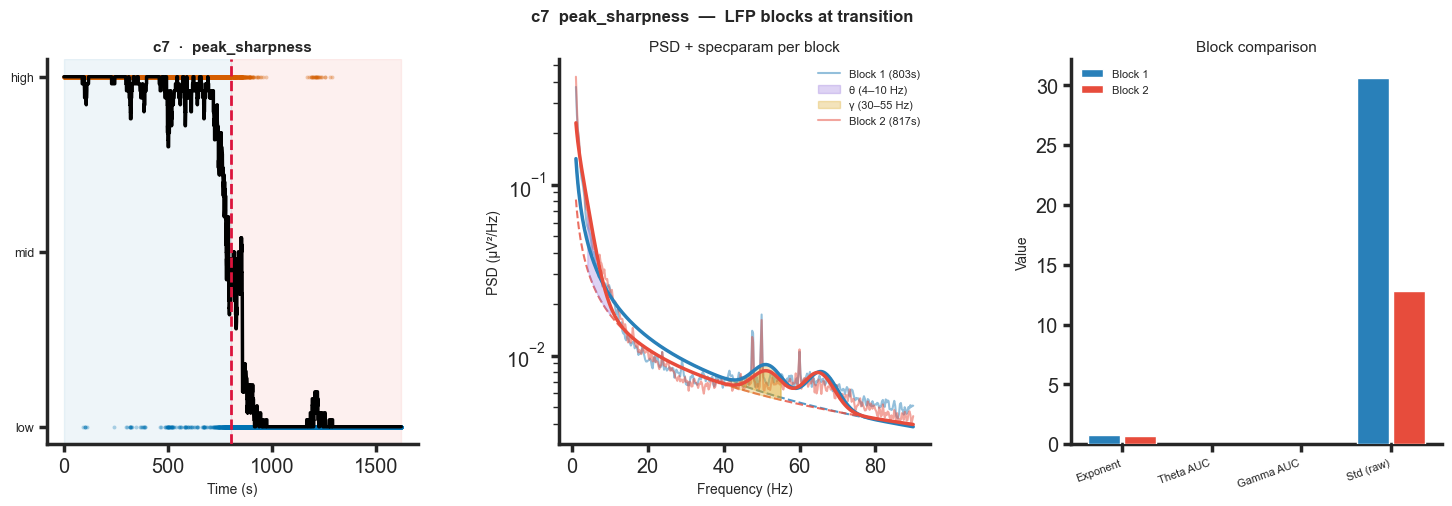

In [ ]:
plot_lfp_block_comparison(
    lfp_block_results,
    df_transitions,
    cluster_pickle_dir,
    rolling_n=50,
)


## Population Δ (post − pre transition)

Sign-corrected so that positive always means the LFP feature increased when the spike-feature
cluster went from a lower to a higher ordinal group (low→high, mid→high, low→mid).
Each dot = one cell. Δ is normalised by the cross-cell SD per LFP feature.

In [ ]:
plot_transition_deltas(lfp_block_results, df_transitions)

In [ ]:
plot_transition_deltas_signed_mean(lfp_block_results, df_transitions)

In [ ]:
plot_transition_deltas_by_celltype(lfp_block_results, df_transitions, DICT_CELL_TYPE)

## Sanity check — pairs without a detected transition

For completeness, plot the rolling cluster label mean for all (cell × feature) pairs that did
*not* meet the sigmoid R² / sharpness threshold. These should look stable or monotone rather
than sigmoidal — if they look like missed transitions, consider loosening the threshold.

In [ ]:
# Sanity check: cells/features that did NOT get a transition
# Load all cluster pickles, find every (cell, feature) pair, subtract the ones in df_transitions
import glob

all_pairs = set()
for pkl_path in sorted(glob.glob(f'{cluster_pickle_dir}/c*_cluster_df.pkl')):
    cid = os.path.basename(pkl_path).replace('_cluster_df.pkl', '')
    df_tmp = pd.read_pickle(pkl_path)
    for col in df_tmp.columns:
        if col.endswith('_cluster') and not col.startswith('spk_times'):
            all_pairs.add((cid, col.replace('_cluster', '')))

transition_pairs = set(zip(df_transitions['cell_id'], df_transitions['spike_feature']))
no_trans_pairs = sorted(all_pairs - transition_pairs)
print(f'{len(transition_pairs)} pairs with transitions, {len(no_trans_pairs)} without')


41 pairs with transitions, 46 without


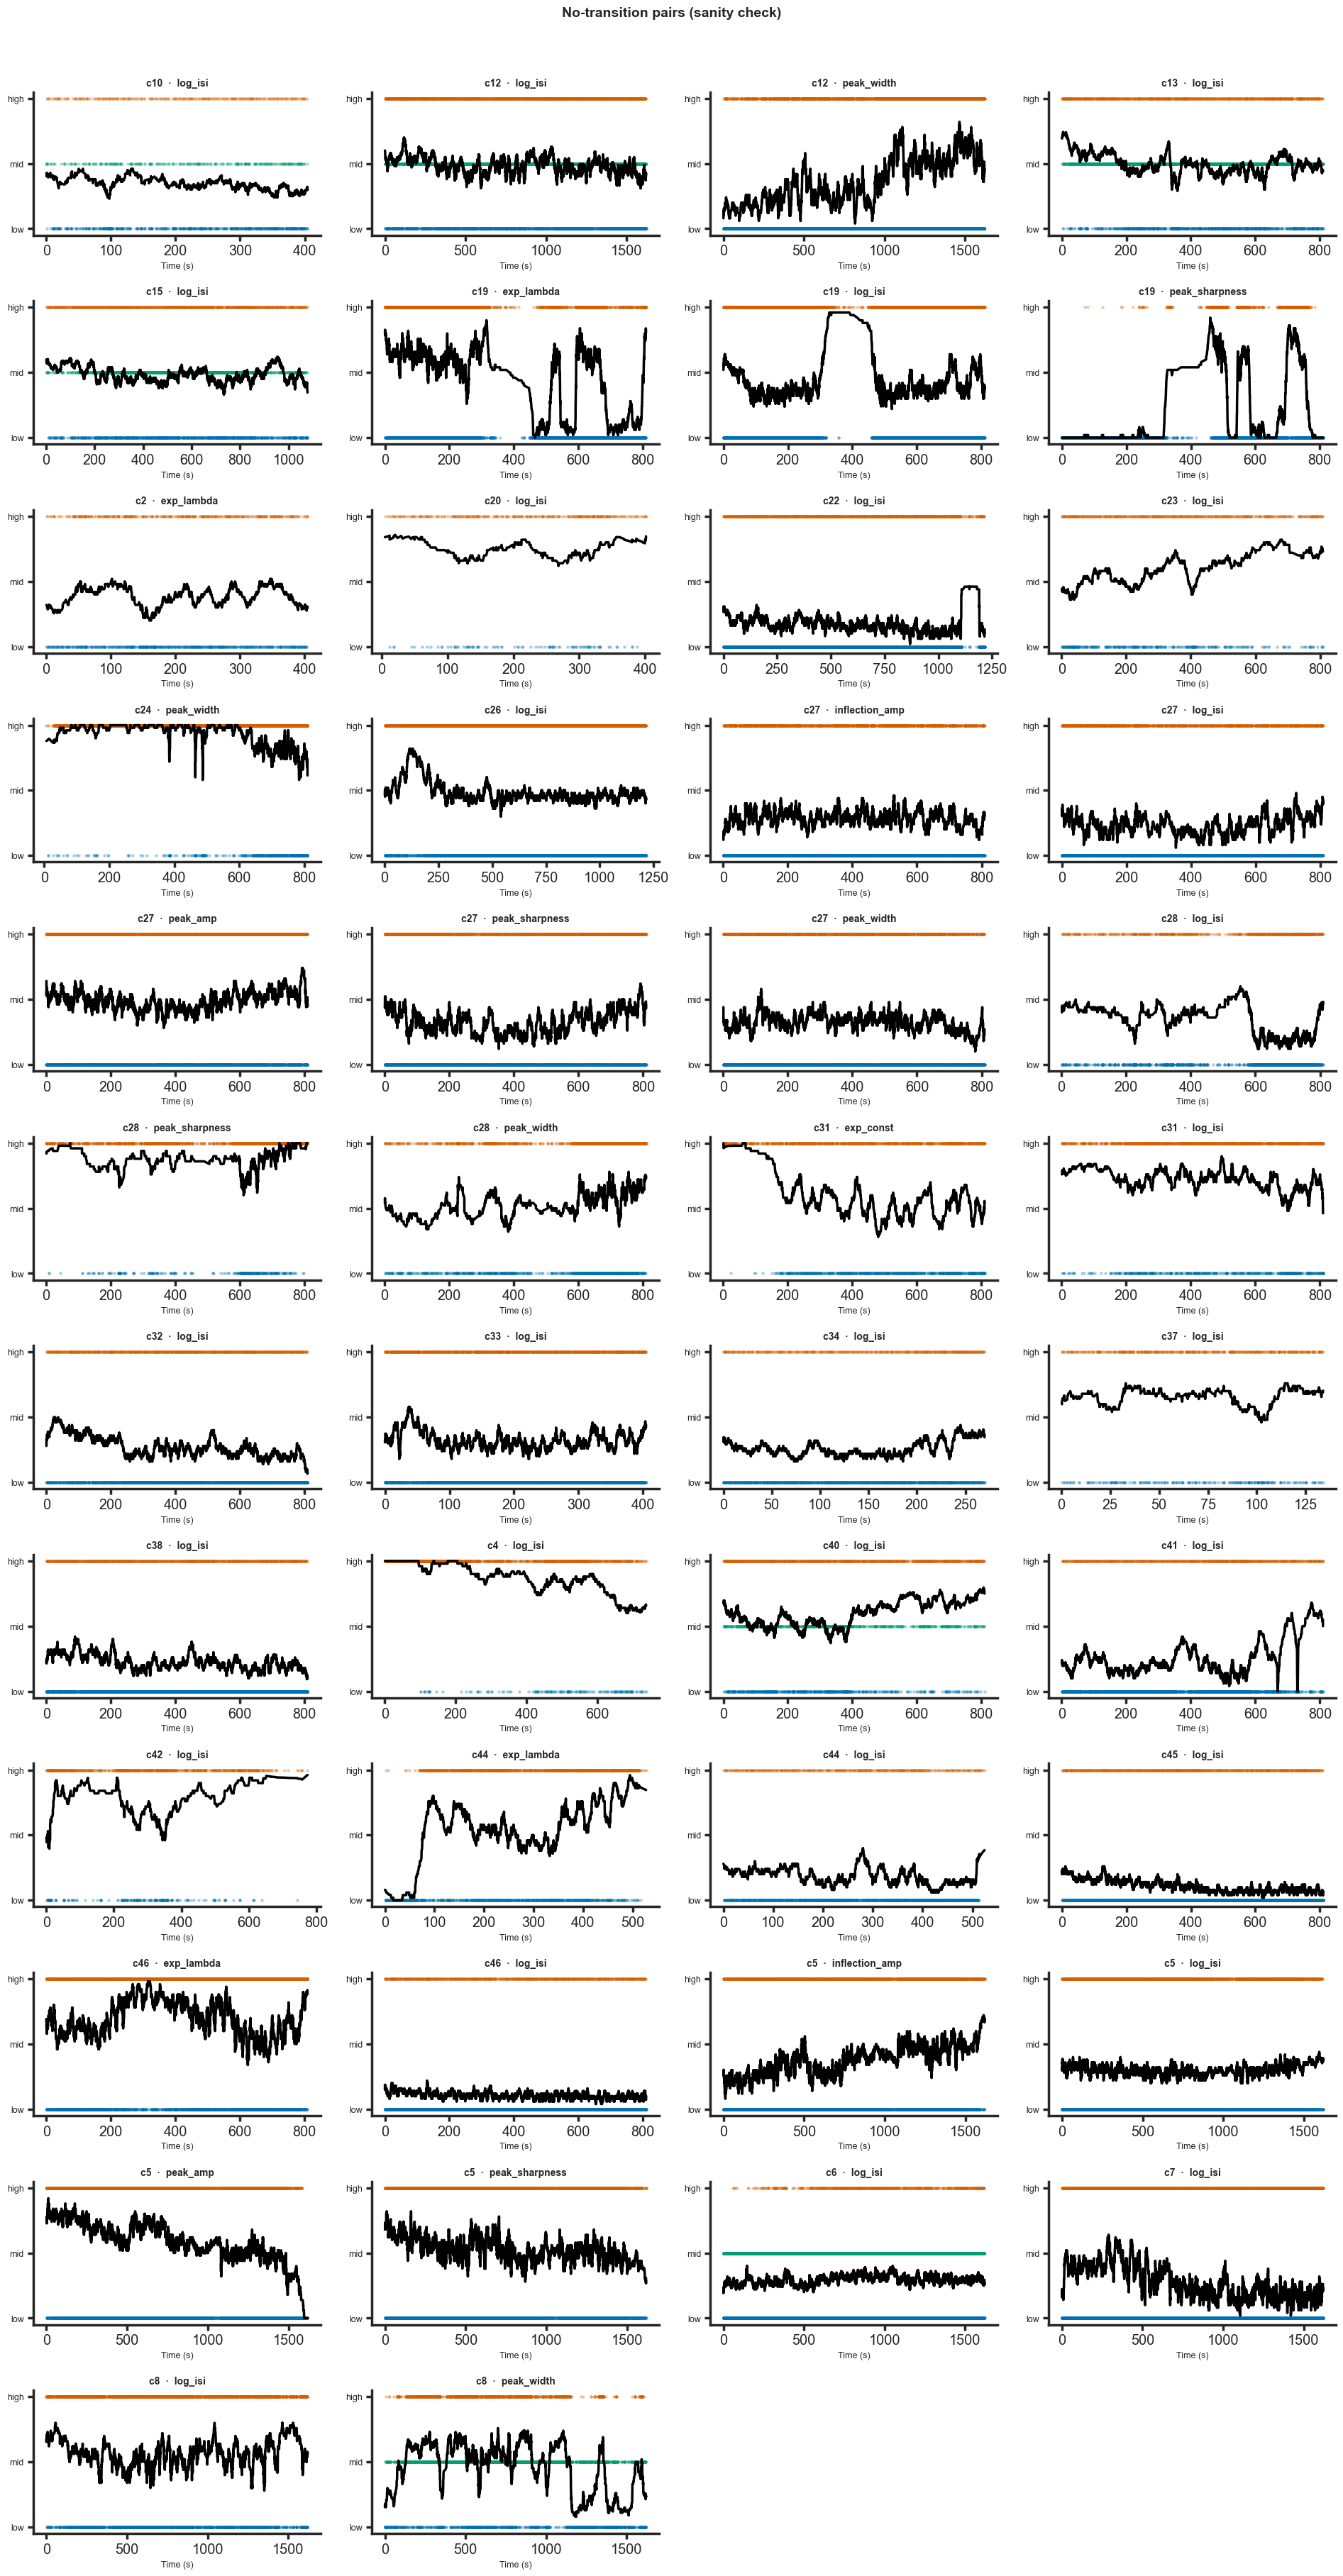

In [ ]:
# Plot rolling mean for no-transition pairs (sanity check they look stable/monotone)

ORDINAL = {'low': 0, 'mid': 1, 'high': 2, 'Low': 0, 'Mid': 1, 'High': 2}
_to_ord = lambda l: ORDINAL.get(str(l).strip(), 1)
CLR = {'low': '#0072B2', 'mid': '#009E73', 'high': '#D55E00',
       'Low': '#0072B2', 'Mid': '#009E73', 'High': '#D55E00'}

n_cols = 4
n_rows = int(np.ceil(len(no_trans_pairs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4.8, n_rows*3.0), squeeze=False)

for ax_i, (cid, feat) in enumerate(no_trans_pairs):
    ax = axes[ax_i // n_cols][ax_i % n_cols]
    try:
        df_tmp = pd.read_pickle(f'{cluster_pickle_dir}/{cid}_cluster_df.pkl')
    except FileNotFoundError:
        ax.set_visible(False); continue
    col = f'{feat}_cluster'
    if col not in df_tmp.columns:
        ax.set_visible(False); continue
    sub = df_tmp[['spk_times_ms', col]].dropna().sort_values('spk_times_ms')
    times  = sub['spk_times_ms'].values / 1000.0
    labels = sub[col].values
    ord_l  = np.array([_to_ord(l) for l in labels], dtype=float)
    for lbl in np.unique(labels):
        mask = labels == lbl
        ax.scatter(times[mask], ord_l[mask], color=CLR.get(str(lbl),'gray'),
                   s=10, alpha=0.35, linewidths=0, zorder=2)
    rm = pd.Series(ord_l).rolling(50, center=True, min_periods=1).mean()
    ax.plot(times, rm.values, color='black', lw=2.5, zorder=4)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['low','mid','high'], fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_title(f'{cid}  ·  {feat}', fontsize=10, fontweight='bold')
    sns.despine(ax=ax)

for ax_i in range(len(no_trans_pairs), n_rows * n_cols):
    axes[ax_i // n_cols][ax_i % n_cols].set_visible(False)

fig.suptitle('No-transition pairs (sanity check)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


## Highlighted transitions

A curated set of (cell × feature) pairs chosen to illustrate the range of transition types in
the dataset: abrupt vs gradual, early vs late in the recording, and different spike features.
These panels are suitable for figures.

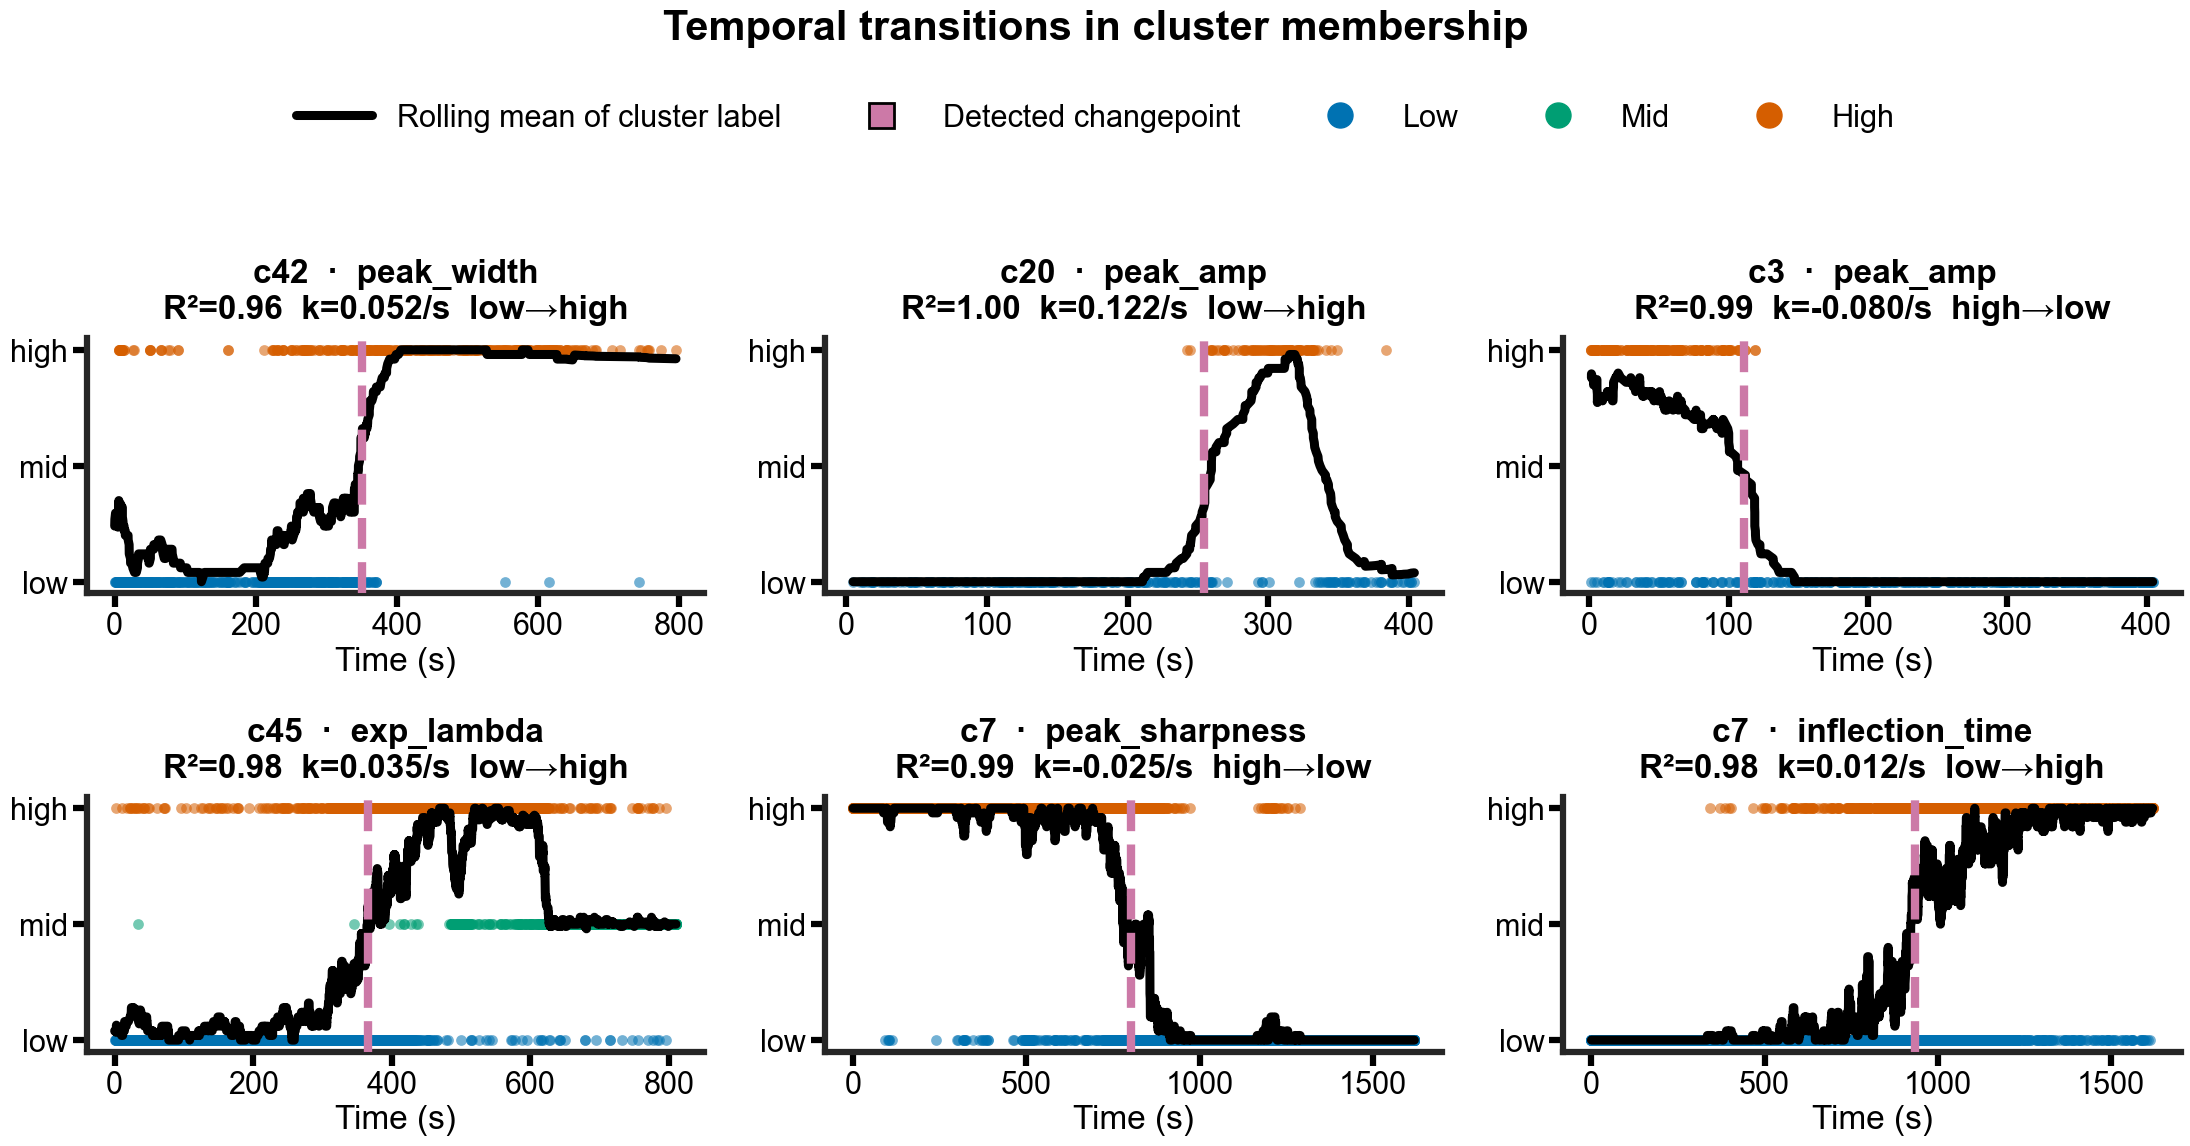

In [ ]:
highlight_selections = [
    ('c42', 'peak_width'),
    ('c20', 'peak_amp'),
    ('c3',  'peak_amp'),
    ('c45', 'exp_lambda'),
    ('c7',  'peak_sharpness'),
    ('c7',  'inflection_time'),
]

plot_temporal_transitions_highlights(df_transitions, cluster_pickle_dir,
                                     highlight_selections, n_cols=3, rolling_n=50)

A positive correlation between temporal ρ and nRMSE is a warning: cells where cluster membership is most time-dependent also look most different between clusters — but that difference may just reflect recording instability, not biology.  This is why we explicitly select high-difference / time-independent cells for priority LFP analysis.